In [ ]:
# -*- coding: utf-8 -*-
"""
SBA Final Project — End-to-End Workflow
Final test protected. EDA on development data. Full dev set for modeling.
Colab-compatible. Parquet + CSV fallback.
"""

'\nSBA Final Project — End-to-End Workflow\nFinal test protected. EDA on development data. Full dev set for modeling.\nColab-compatible. Parquet + CSV fallback.\n'



# SBA Loan Default Project — Final Working Notebook



Run cells one by one with Shift+Enter. Do not click "Run all" please:(.

If a cell fails, stop and fix it before moving on.



Protected sections: dataset loading, dev/test split, target, modeling data, train/valid split, profit function, threshold tuning, final test.



You can edit: your EDA section, your feature block, your model block, your tuning search space.



Target: y=0 paid in full, y=1 default. Profit rule: +5% if approve+paid, -25% if approve+default, 0 if deny.


To run your model, set False to True

Final test is protected. I will run it after we freeze the final model and threshold.

## Imports and Colab / Drive setup

In [ ]:
import os, sys, time, warnings
warnings.filterwarnings("ignore")
from pathlib import Path

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, FunctionTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, brier_score_loss,
)
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier, RandomForestClassifier, AdaBoostClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis

In [ ]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 8.9 MB/s eta 0:00:00


In [ ]:
from sklearn.ensemble import HistGradientBoostingClassifier
import optuna
import xgboost as xgb
import lightgbm as lgb

In [ ]:
pd.set_option("display.max_columns", None); pd.set_option("display.width", 200)
plt.rcParams.update({"figure.dpi": 100, "font.size": 10})

In [ ]:
IN_COLAB = "google.colab" in sys.modules
if IN_COLAB:
    from google.colab import drive; drive.mount("/content/drive")

Mounted at /content/drive


Here Colab will ask for your permission to connect to your Drive, make sure u grant it permission.
If things somehow do not work, then, create a shortcut to this Final Project drive folder to your own Drive.

In [ ]:
#%% Direct dataset download from Google Drive link
# This bypasses Drive shortcut/path issues.
# It downloads the dataset into the Colab runtime at /content/.

!pip -q install gdown

from pathlib import Path
import gdown
import os

DATA_FILE_ID = "1wMJ6u9VcoBhuwkcnX-j8CvKX6wbJXOwj"
DATA_PATH = "/content/sba_enriched_eda_dataset.parquet"
FILE_TYPE = "parquet"

data_path_obj = Path(DATA_PATH)

if not data_path_obj.exists():
    print("Downloading dataset directly from Google Drive...")
    gdown.download(
        id=DATA_FILE_ID,
        output=DATA_PATH,
        quiet=False,
        fuzzy=True
    )
else:
    print("Dataset already downloaded in this Colab runtime.")

print(f"Working dir: {os.getcwd()}")
print(f"Dataset: {DATA_PATH} ({FILE_TYPE})")
print("File exists:", data_path_obj.exists())
print("Size MB:", round(data_path_obj.stat().st_size / 1e6, 2) if data_path_obj.exists() else "NOT FOUND")

if not data_path_obj.exists() or data_path_obj.stat().st_size < 1_000_000:
    raise FileNotFoundError(
        "Download failed or file is too small. Make sure the Google Drive file is shared as 'Anyone with the link can view'."
    )

Downloading...
From: https://drive.google.com/uc?id=1wMJ6u9VcoBhuwkcnX-j8CvKX6wbJXOwj
To: /content/sba_enriched_eda_dataset.parquet
100%|██████████| 52.6M/52.6M [00:00<00:00, 92.8MB/s]

Working dir: /content
Dataset: /content/sba_enriched_eda_dataset.parquet (parquet)
File exists: True
Size MB: 52.56


In [ ]:
DATA_PATH = '/content/sba_enriched_eda_dataset.parquet'
FILE_TYPE = 'parquet'

print(f"Working dir: {os.getcwd()}")
print(f"Dataset: {DATA_PATH or 'NOT FOUND'} ({FILE_TYPE})")
if DATA_PATH is None:
    print("ERROR: Cannot find dataset. If using shared Drive, add a shortcut to My Drive and rerun.")
    sys.exit(1)

Working dir: /content
Dataset: /content/sba_enriched_eda_dataset.parquet (parquet)


## Load full finalized dataset

In [ ]:
df_full = None
if FILE_TYPE == "parquet":
    try: df_full = pd.read_parquet(DATA_PATH)
    except Exception as e:
        print(f"Parquet failed to load from {DATA_PATH}. Error: {e}")
        # The data path is explicitly set and confirmed. No need to search.
        # Removing redundant logic that uses undefined BASE_DIRS and CSV_CANDIDATES.

# This block will not be reached if FILE_TYPE is 'parquet' and DATA_PATH is reliable.
# If FILE_TYPE changes to 'csv' dynamically or this is an original csv loading path, keep it.
if FILE_TYPE == "csv" and df_full is None:
    try: df_full = pd.read_csv(DATA_PATH)
    except Exception as e:
        print(f"CSV failed to load from {DATA_PATH}. Error: {e}")

if df_full is None: print("ERROR: Could not load dataset."); sys.exit(1)

In [ ]:
print(f"Loaded: {DATA_PATH} ({FILE_TYPE}), shape={df_full.shape}, DR={df_full['y'].mean():.4f}")

Loaded: /content/sba_enriched_eda_dataset.parquet (parquet), shape=(866082, 100), DR=0.1727


In [ ]:
_PP = Path(DATA_PATH).resolve()
PROJECT_DIR = _PP.parents[1] if "research_outputs" in str(_PP) else _PP.parent
FINAL_OUT = PROJECT_DIR / "research_outputs" / "final_workflow_outputs"
FINAL_OUT.mkdir(parents=True, exist_ok=True)
print(f"Output dir: {FINAL_OUT}")

Output dir: /content/research_outputs/final_workflow_outputs


## 3. Create era labels and NAICS string

In [ ]:
df_full["era"] = "pre"
df_full.loc[df_full["approval_year"].between(2007, 2010), "era"] = "crisis"
df_full.loc[df_full["approval_year"] >= 2011, "era"] = "post"

In [ ]:
df_full["NAICS_sector_str"] = (
    pd.to_numeric(df_full["NAICS_sector"], errors="coerce").astype("Int64").astype(str))

In [ ]:
RANDOM_STATE = 1



# Data Split Design



1. `df_full` — full dataset

2. `df_dev` — development data for EDA, feature design, model training, and validation

3. `df_final_test` — untouched final test, do not use until the final model is frozen



EDA runs on `df_dev`. Modeling uses the full development set. The dev set is split into train (fit) and validation (tune). Final test remains untouched.

## 4. Split full data into development and untouched final test

In [ ]:
try:
    strat_key = df_full["y"].astype(str) + "_" + df_full["era"].astype(str)
    df_dev, df_final_test = train_test_split(df_full, test_size=0.20, random_state=RANDOM_STATE, stratify=strat_key)
except Exception:
    df_dev, df_final_test = train_test_split(df_full, test_size=0.20, random_state=RANDOM_STATE, stratify=df_full["y"])

In [ ]:
print("Full:", len(df_full), f"DR={df_full['y'].mean():.4f}")
print("Dev:", len(df_dev), f"DR={df_dev['y'].mean():.4f}")
print("Test:", len(df_final_test), f"DR={df_final_test['y'].mean():.4f}")
for label, subset in [("Full",df_full),("Dev",df_dev),("Test",df_final_test)]:
    print(f"  {label} eras:", {e: len(subset[subset["era"]==e]) for e in ["pre","crisis","post"]})
print("Dev DR by era:", {e: round(df_dev[df_dev["era"]==e]["y"].mean(),4) for e in ["pre","crisis","post"]})

Full: 866082 DR=0.1727
Dev: 692865 DR=0.1727
Test: 173217 DR=0.1727
  Full eras: {'pre': 715567, 'crisis': 133951, 'post': 16564}
  Dev eras: {'pre': 572453, 'crisis': 107160, 'post': 13252}
  Test eras: {'pre': 143114, 'crisis': 26791, 'post': 3312}
Dev DR by era: {'pre': np.float64(0.1427), 'crisis': np.float64(0.3464), 'post': np.float64(0.0629)}


## 5. EDA on development data only

In [ ]:
df_eda = df_dev.copy()
AMOUNT_COL = "DisbursementGross" if "DisbursementGross" in df_eda.columns else "GrAppv"
print("Amount column:", AMOUNT_COL)

Amount column: DisbursementGross


In [ ]:
OUT_DIR = FINAL_OUT / "baseline_eda"
OUT_DIR.mkdir(parents=True, exist_ok=True)

Target distribution

In [ ]:
tgt = df_eda["y"].value_counts().rename({0:"Paid",1:"Default"})
print("Target distribution:"); print(tgt)
pd.DataFrame({"outcome":tgt.index,"count":tgt.values}).to_csv(OUT_DIR/"target_distribution_table.csv",index=False)
fig,ax=plt.subplots(figsize=(5,4))
ax.bar(["Paid","Default"],tgt.values,color=["#2ecc71","#e74c3c"],edgecolor="black")
for i,v in enumerate(tgt.values): ax.text(i,v+len(df_eda)*0.005,f"{v:,}",ha="center",fontweight="bold")
ax.set_title("Loan Outcome Distribution"); plt.tight_layout(); plt.savefig(OUT_DIR/"target_distribution.png",dpi=120); plt.close()
print(f"Default rate: {df_eda['y'].mean():.4f}")

Target distribution:
y
Paid       573195
Default    119670
Name: count, dtype: int64
Default rate: 0.1727


# Baseline EDA: Original SBA EDA

This section should only produce the original SBA clues that motivate each research thread.

Hai Anh — 5.1 Borrower Fragility and Macro Stress
- target distribution
- term bucket
- loan-size bucket
- employee-count bucket

Question:
Are short-term, small-loan, and micro-business borrowers especially vulnerable to macro stress?

Hai An — 5.2 Industry Cyclicality and Local Business Ecosystem
- NAICS default rates
- state × NAICS hotspots
- NewExist
- same_state_bank

Question:
Are high-risk industries risky on their own, or mainly when local housing and industry conditions weaken?

Huyen Anh — 5.3 Geography, Disaster Exposure, and Tourism Vulnerability
- state default rates
- tourism industry baseline flag
- coastal state baseline flag
- disaster-sensitive sector baseline flag

Question:
Do geography and sector exposure explain why some borrowers become much riskier after disasters?

Do not treat this as a chart dump.
Every subsection should support:
original SBA clue -> external hypothesis -> EDA evidence -> feature decision

**Hải Anh**

In [ ]:

import matplotlib.ticker as mticker

OUT_HAH_EDA = FINAL_OUT / "hai_anh_baseline_eda"
OUT_HAH_EDA.mkdir(parents=True, exist_ok=True)

# Colour palette
C_DEFAULT = "#e74c3c"   # red   = default / high risk
C_PAID    = "#2ecc71"   # green = paid / low risk
C_MID     = "#f39c12"   # amber = middle bucket
C_BLUE    = "#3498db"   # blue  = volume / count bars
C_GRAY    = "#95a5a6"   # gray  = baseline / reference

AMOUNT_COL_EDA = "DisbursementGross" if "DisbursementGross" in df_eda.columns else "GrAppv"
dr_overall     = df_eda["y"].mean()
n_total        = len(df_eda)

print(f"Setup OK — DR={dr_overall:.4f}, n={n_total:,}, amount col='{AMOUNT_COL_EDA}'")
print(f"Output folder: {OUT_HAH_EDA}")

Setup OK — DR=0.1727, n=692,865, amount col='DisbursementGross'
Output folder: /content/research_outputs/final_workflow_outputs/hai_anh_baseline_eda


**Hai Anh**

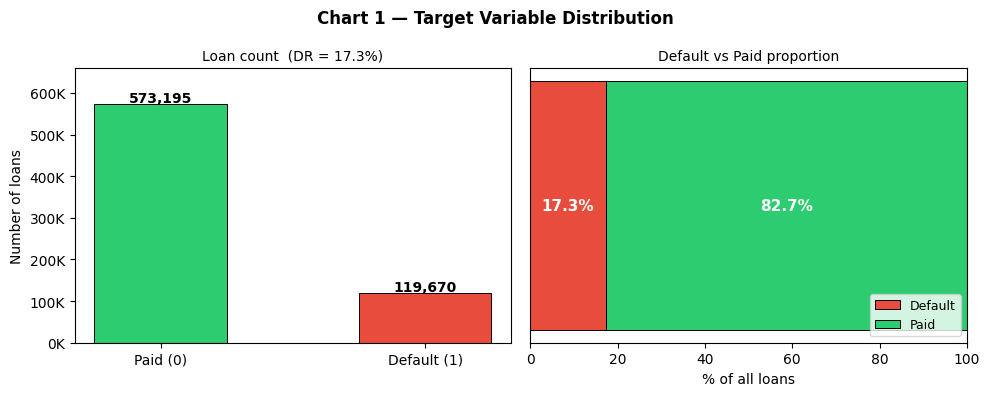

Chart 1 saved.  DR=17.3%  n=692,865


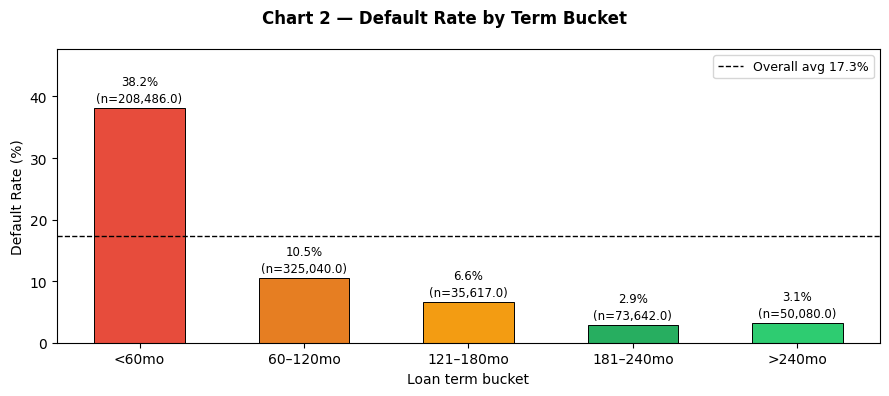

Chart 2 saved.
                n      dr
_term5                   
<60mo      208486  0.3817
60–120mo   325040  0.1047
121–180mo   35617  0.0660
181–240mo   73642  0.0293
>240mo      50080  0.0313


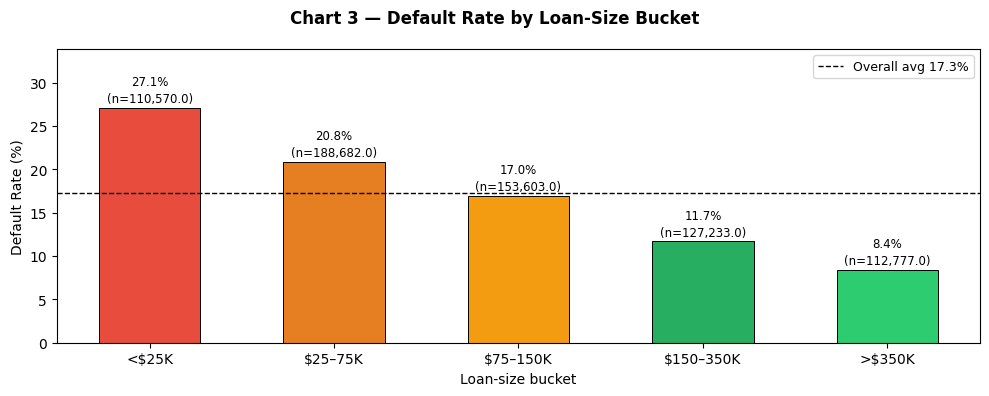

Chart 3 saved.
                n      dr
_size5                   
<$25K      110570  0.2709
$25–75K    188682  0.2085
$75–150K   153603  0.1696
$150–350K  127233  0.1167
>$350K     112777  0.0840


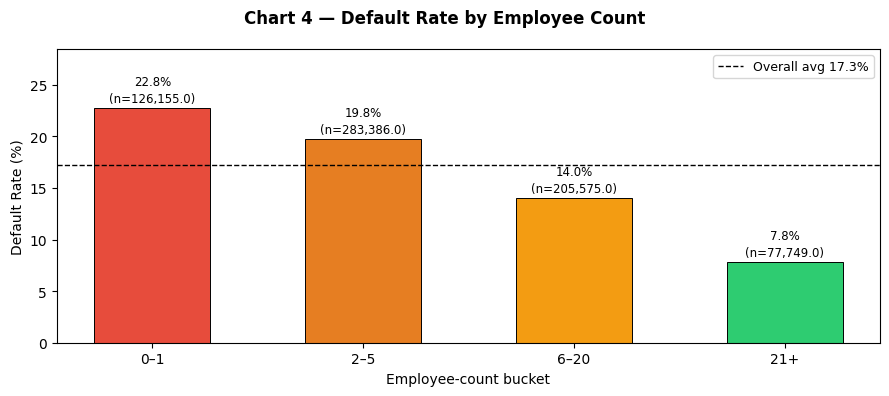

Chart 4 saved.
            n      dr
_emp4                
0–1    126155  0.2278
2–5    283386  0.1977
6–20   205575  0.1401
21+     77749  0.0784

Chart 4 — Descriptive Table
             variable      n default_rate  p25 median   p75   mean                    note
          y (default) 692865        17.3%    —      —     — 0.1727   1 = default, 0 = paid
        Term (months) 692865            —   60     84   120  109.3 Loan maturity in months
         Term = <60mo 208486        38.2%    —      —     —      —                        
      Term = 60–120mo 325040        10.5%    —      —     —      —                        
     Term = 121–180mo  35617         6.6%    —      —     —      —                        
     Term = 181–240mo  73642         2.9%    —      —     —      —                        
        Term = >240mo  50080         3.1%    —      —     —      —                        
DisbursementGross ($) 692865            — $40K  $100K $235K  $201K   Gross approved amount
     

In [ ]:

_C_DEFAULT = "#e74c3c"
_C_PAID    = "#2ecc71"
_C_MID     = "#f39c12"
_C_BLUE    = "#3498db"

AMOUNT_COL_EDA = "DisbursementGross" if "DisbursementGross" in df_eda.columns else "GrAppv"
_dr_overall    = df_eda["y"].mean()
_n_total       = len(df_eda)

OUT_HAH = FINAL_OUT / "hai_anh_eda"
OUT_HAH.mkdir(parents=True, exist_ok=True)

# ── buckets ───────────────────────────────────────────────────────────────────
TERM_BINS   = [-1, 60, 120, 180, 240, np.inf]
TERM_LABELS = ["<60mo", "60–120mo", "121–180mo", "181–240mo", ">240mo"]
SIZE_BINS   = [-1, 25_000, 75_000, 150_000, 350_000, np.inf]
SIZE_LABELS = ["<$25K", "$25–75K", "$75–150K", "$150–350K", ">$350K"]

df_eda["_term5"] = pd.cut(df_eda["Term"],          bins=TERM_BINS, labels=TERM_LABELS)
df_eda["_size5"] = pd.cut(df_eda[AMOUNT_COL_EDA],  bins=SIZE_BINS, labels=SIZE_LABELS)

term5 = df_eda.groupby("_term5", observed=False)["y"].agg(n="count", dr="mean").round(4)
size5 = df_eda.groupby("_size5", observed=False)["y"].agg(n="count", dr="mean").round(4)

# =============================================================================
# CHART 1 — Target distribution
# =============================================================================
tgt = df_eda["y"].value_counts().sort_index()   # 0=Paid, 1=Default

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
fig.suptitle("Chart 1 — Target Variable Distribution", fontweight="bold")

# Left: count bars
ax = axes[0]
bars = ax.bar(["Paid (0)", "Default (1)"], tgt.values,
              color=[_C_PAID, _C_DEFAULT], edgecolor="black", linewidth=0.7, width=0.5)
for bar, v in zip(bars, tgt.values):
    ax.text(bar.get_x() + bar.get_width()/2, v + _n_total * 0.008,
            f"{v:,}", ha="center", fontsize=10, fontweight="bold")
ax.set_ylabel("Number of loans")
ax.set_title(f"Loan count  (DR = {_dr_overall:.1%})", fontsize=10)
ax.yaxis.set_major_formatter(
    plt.matplotlib.ticker.FuncFormatter(lambda x, _: f"{x/1e3:.0f}K"))
ax.set_ylim(0, tgt.max() * 1.15)

# Right: stacked proportion bar
ax = axes[1]
ax.barh([0], [_dr_overall * 100],
        color=_C_DEFAULT, height=0.4, edgecolor="black", linewidth=0.7, label="Default")
ax.barh([0], [(1 - _dr_overall) * 100], left=[_dr_overall * 100],
        color=_C_PAID,    height=0.4, edgecolor="black", linewidth=0.7, label="Paid")
ax.text(_dr_overall * 50,        0, f"{_dr_overall*100:.1f}%",
        ha="center", va="center", fontsize=11, fontweight="bold", color="white")
ax.text(_dr_overall*100 + (1-_dr_overall)*50, 0, f"{(1-_dr_overall)*100:.1f}%",
        ha="center", va="center", fontsize=11, fontweight="bold", color="white")
ax.set_xlim(0, 100); ax.set_yticks([]); ax.set_xlabel("% of all loans")
ax.set_title("Default vs Paid proportion", fontsize=10)
ax.legend(fontsize=9, loc="lower right")

plt.tight_layout()
plt.savefig(OUT_HAH / "chart1_target_distribution.png", dpi=130)
plt.show()
print(f"Chart 1 saved.  DR={_dr_overall:.1%}  n={_n_total:,}")


# =============================================================================
# CHART 2 — Term default-rate bar chart
# =============================================================================
_term_colors = [_C_DEFAULT, "#e67e22", _C_MID, "#27ae60", _C_PAID]

fig, ax = plt.subplots(figsize=(9, 4))
fig.suptitle("Chart 2 — Default Rate by Term Bucket", fontweight="bold")

x = np.arange(len(TERM_LABELS))
bars = ax.bar(x, term5["dr"] * 100, color=_term_colors,
              edgecolor="black", linewidth=0.7, width=0.55)
for bar, (_, row) in zip(bars, term5.iterrows()):
    ax.text(bar.get_x() + bar.get_width()/2,
            row["dr"] * 100 + 0.5,
            f"{row['dr']*100:.1f}%\n(n={row['n']:,})",
            ha="center", va="bottom", fontsize=8.5, linespacing=1.4)

ax.axhline(_dr_overall * 100, color="black", linestyle="--",
           linewidth=1, label=f"Overall avg {_dr_overall*100:.1f}%")
ax.set_xticks(x); ax.set_xticklabels(TERM_LABELS, fontsize=10)
ax.set_ylabel("Default Rate (%)"); ax.set_xlabel("Loan term bucket")
ax.set_ylim(0, term5["dr"].max() * 100 * 1.25)
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(OUT_HAH / "chart2_term_default_rate.png", dpi=130)
plt.show()
print("Chart 2 saved.")
print(term5.to_string())


# =============================================================================
# CHART 3 — Loan-size default-rate bar chart
# =============================================================================
fig, ax = plt.subplots(figsize=(10, 4))
fig.suptitle("Chart 3 — Default Rate by Loan-Size Bucket", fontweight="bold")

x = np.arange(len(SIZE_LABELS))
bars = ax.bar(x, size5["dr"] * 100, color=_term_colors,
              edgecolor="black", linewidth=0.7, width=0.55)
for bar, (_, row) in zip(bars, size5.iterrows()):
    ax.text(bar.get_x() + bar.get_width()/2,
            row["dr"] * 100 + 0.3,
            f"{row['dr']*100:.1f}%\n(n={row['n']:,})",
            ha="center", va="bottom", fontsize=8.5, linespacing=1.4)

ax.axhline(_dr_overall * 100, color="black", linestyle="--",
           linewidth=1, label=f"Overall avg {_dr_overall*100:.1f}%")
ax.set_xticks(x); ax.set_xticklabels(SIZE_LABELS, fontsize=10)
ax.set_ylabel("Default Rate (%)"); ax.set_xlabel("Loan-size bucket")
ax.set_ylim(0, size5["dr"].max() * 100 * 1.25)
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(OUT_HAH / "chart3_loansize_default_rate.png", dpi=130)
plt.show()
print("Chart 3 saved.")
print(size5.to_string())

# =============================================================================
# CHART 4 — Employee-count default-rate chart
# =============================================================================
EMP_BINS = [-1, 1, 5, 20, np.inf]
EMP_LABELS = ["0–1", "2–5", "6–20", "21+"]

df_eda["_emp4"] = pd.cut(df_eda["NoEmp"], bins=EMP_BINS, labels=EMP_LABELS)
emp4 = df_eda.groupby("_emp4", observed=False)["y"].agg(n="count", dr="mean").round(4)

fig, ax = plt.subplots(figsize=(9, 4))
fig.suptitle("Chart 4 — Default Rate by Employee Count", fontweight="bold")

_emp_colors = [_C_DEFAULT, "#e67e22", _C_MID, _C_PAID]
x = np.arange(len(EMP_LABELS))
bars = ax.bar(x, emp4["dr"] * 100, color=_emp_colors, edgecolor="black", linewidth=0.7, width=0.55)

for bar, (_, row) in zip(bars, emp4.iterrows()):
    ax.text(
        bar.get_x() + bar.get_width()/2,
        row["dr"] * 100 + 0.3,
        f"{row['dr']*100:.1f}%\n(n={row['n']:,})",
        ha="center", va="bottom", fontsize=8.5, linespacing=1.4
    )

ax.axhline(_dr_overall * 100, color="black", linestyle="--", linewidth=1,
           label=f"Overall avg {_dr_overall*100:.1f}%")
ax.set_xticks(x)
ax.set_xticklabels(EMP_LABELS, fontsize=10)
ax.set_ylabel("Default Rate (%)")
ax.set_xlabel("Employee-count bucket")
ax.set_ylim(0, emp4["dr"].max() * 100 * 1.25)
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(OUT_HAH / "chart4_employee_default_rate.png", dpi=130)
plt.show()

emp4.to_csv(OUT_HAH / "employee_count_default_rate_table.csv")
print("Chart 4 saved.")
print(emp4.to_string())

# =============================================================================
# CHART 5 — Descriptive table (Term, Loan Size, Target)
# printed as formatted table + saved to CSV
# =============================================================================
desc_rows = []

# Target
desc_rows.append({
    "variable": "y (default)",
    "n": _n_total,
    "default_rate": f"{_dr_overall:.1%}",
    "p25": "—", "median": "—", "p75": "—",
    "mean": f"{_dr_overall:.4f}",
    "note": "1 = default, 0 = paid"
})

# Term
s = df_eda["Term"].dropna()
desc_rows.append({
    "variable": "Term (months)",
    "n": len(s),
    "default_rate": "—",
    "p25": f"{s.quantile(0.25):.0f}",
    "median": f"{s.median():.0f}",
    "p75": f"{s.quantile(0.75):.0f}",
    "mean": f"{s.mean():.1f}",
    "note": "Loan maturity in months"
})

# Term DR by bucket
for label, (_, row) in zip(TERM_LABELS, term5.iterrows()):
    desc_rows.append({
        "variable": f"  Term = {label}",
        "n": int(row["n"]),
        "default_rate": f"{row['dr']:.1%}",
        "p25": "—", "median": "—", "p75": "—", "mean": "—",
        "note": ""
    })

# Loan size
a = df_eda[AMOUNT_COL_EDA].dropna()
desc_rows.append({
    "variable": f"{AMOUNT_COL_EDA} ($)",
    "n": len(a),
    "default_rate": "—",
    "p25": f"${a.quantile(0.25)/1e3:.0f}K",
    "median": f"${a.median()/1e3:.0f}K",
    "p75": f"${a.quantile(0.75)/1e3:.0f}K",
    "mean": f"${a.mean()/1e3:.0f}K",
    "note": "Gross approved amount"
})

# Loan size DR by bucket
for label, (_, row) in zip(SIZE_LABELS, size5.iterrows()):
    desc_rows.append({
        "variable": f"  Size = {label}",
        "n": int(row["n"]),
        "default_rate": f"{row['dr']:.1%}",
        "p25": "—", "median": "—", "p75": "—", "mean": "—",
        "note": ""
    })

desc_df = pd.DataFrame(desc_rows)
desc_df.to_csv(OUT_HAH / "chart4_descriptive_table.csv", index=False)

print("\nChart 4 — Descriptive Table")
print("=" * 80)
print(desc_df.to_string(index=False))
print("=" * 80)
print("Chart 4 saved.")

# cleanup temp columns
df_eda.drop(columns=["_term5", "_size5"], errors="ignore", inplace=True)
print(f"\nAll 4 charts saved to: {OUT_HAH}")

## 6. Descriptive statistics

In [ ]:
desc_cols = ["Term","NoEmp","CreateJob","RetainedJob","GrAppv","SBA_Appv"]
desc_cols = [c for c in desc_cols if c in df_eda.columns]
desc_numeric = []
for col in desc_cols:
    s = df_eda[col].dropna()
    desc_numeric.append({"variable":col,"p5":s.quantile(0.05),"p25":s.quantile(0.25),
                         "median":s.median(),"p75":s.quantile(0.75),"p95":s.quantile(0.95),
                         "mean":s.mean(),"observations":len(s)})
pd.DataFrame(desc_numeric).round(2).to_csv(FINAL_OUT/"descriptive_numeric.csv",index=False)

In [ ]:
cat_desc = ["State","BankState","NewExist","UrbanRural","NAICS_sector","LowDoc_clean","RevLineCr_clean"]
cat_desc = [c for c in cat_desc if c in df_eda.columns]
desc_cat = []
for col in cat_desc:
    for val in df_eda[col].dropna().unique():
        seg = df_eda[df_eda[col]==val]
        desc_cat.append({"variable":col,"level":str(val),"observations":len(seg),"default_rate":round(seg["y"].mean(),4)})
pd.DataFrame(desc_cat).to_csv(FINAL_OUT/"descriptive_categorical.csv",index=False)
print("Descriptive stats saved.")

Descriptive stats saved.


## 7. External EDA: Hai Anh — Local Economy / Weak Borrowers



# External EDA — Hai Anh:



You cover: inflation, oil shock, income decline, bank failures, and the borrower-fragility interactions that go with them.

Collect: high inflation table, inflation × firm-size table, oil shock × supply-chain table, income decline × consumer-sector table, and bank failure table.

Write: what pattern did you find? Keep, reject, or report only? What does it mean for approval decisions for fragile borrowers?

In [ ]:
OUT_HAH = FINAL_OUT / "hai_anh_external_eda"; OUT_HAH.mkdir(parents=True, exist_ok=True)

In [ ]:
if "high_inflation_flag_lag1" in df_eda.columns:
    hi = df_eda.groupby("high_inflation_flag_lag1")["y"].agg(["count","mean"]).round(4)
    hi.to_csv(OUT_HAH/"high_inflation_table.csv")
    print("High inflation:"); print(hi)
    df_eda["_eb2"] = pd.cut(df_eda["NoEmp"],bins=[-1,5,20,np.inf],labels=["Micro(0-5)","Small(6-20)","Large(21+)"])
    hi_firm = df_eda.groupby(["_eb2","high_inflation_flag_lag1"],observed=False)["y"].agg(["count","mean"]).round(4)
    hi_firm.to_csv(OUT_HAH/"inflation_firm_size_table.csv")
    print("Inflation x firm size:"); print(hi_firm)
    fig,ax=plt.subplots(figsize=(8,5))
    sizes=["Micro(0-5)","Small(6-20)","Large(21+)"]
    x=np.arange(len(sizes)); w=0.3
    for j,(lbl,v) in enumerate([("Normal",0),("High infl",1)]):
        vals=[df_eda[(df_eda["_eb2"]==s)&(df_eda["high_inflation_flag_lag1"]==v)]["y"].mean()*100 for s in sizes]
        ax.bar(x+j*w,vals,w,label=lbl,color=["#2ecc71","#e74c3c"][j],edgecolor="black")
    ax.set_xticks(x+w/2); ax.set_xticklabels(sizes)
    ax.set_title("Inflation x Firm Size"); ax.set_ylabel("Default Rate (%)"); ax.legend()
    plt.tight_layout(); plt.savefig(OUT_HAH/"inflation_firm_size.png",dpi=120); plt.close()

High inflation:
                           count    mean
high_inflation_flag_lag1                
0.0                       560246  0.1507
1.0                       132619  0.2658
Inflation x firm size:
                                       count    mean
_eb2        high_inflation_flag_lag1                
Micro(0-5)  0.0                       325806  0.1810
            1.0                        83735  0.3081
Small(6-20) 0.0                       169395  0.1231
            1.0                        36180  0.2201
Large(21+)  0.0                        65045  0.0708
            1.0                        12704  0.1173


In [ ]:
if "oil_shock_flag_lag1" in df_eda.columns:
    oi = df_eda.groupby("oil_shock_flag_lag1")["y"].agg(["count","mean"]).round(4)
    oi.to_csv(OUT_HAH/"oil_shock_table.csv")
    print("Oil shock:"); print(oi)

Oil shock:
                      count    mean
oil_shock_flag_lag1                
0.0                  475024  0.1543
1.0                  217841  0.2129


In [ ]:
if "real_income_decline_flag_lag1" in df_eda.columns:
    ri = df_eda.groupby("real_income_decline_flag_lag1")["y"].agg(["count","mean"]).round(4)
    ri.to_csv(OUT_HAH/"income_decline_table.csv")
    print("Income decline:"); print(ri)

Income decline:
                                count    mean
real_income_decline_flag_lag1                
0.0                            603381  0.1758
1.0                             89479  0.1520


In [ ]:
if "state_bank_failures_12m" in df_eda.columns and "state_bank_failures_data_available" in df_eda.columns:
    fdic_ok = df_eda[df_eda["state_bank_failures_data_available"]==1]
    bk = fdic_ok.groupby((fdic_ok["state_bank_failures_12m"]>0).astype(int))["y"].agg(["count","mean"]).round(4)
    bk.to_csv(OUT_HAH/"bank_failures_table.csv")
    print("Bank failures:"); print(bk)

Bank failures:
                          count    mean
state_bank_failures_12m                
0                        349246  0.2641
1                         73263  0.1698


In [ ]:
if all(c in df_eda.columns for c in ["oil_shock_flag_lag1", "NAICS_sector_str"]):
    supply_codes = ["23", "31", "32", "33", "42", "48", "49"]
    df_eda["_supply_chain"] = df_eda["NAICS_sector_str"].isin(supply_codes).astype(int)

    oil_supply = (
        df_eda.groupby(["_supply_chain", "oil_shock_flag_lag1"])["y"]
        .agg(["count", "mean"])
        .round(4)
    )
    oil_supply.to_csv(OUT_HAH / "oil_shock_supply_chain_table.csv")
    print("Oil shock × supply chain:")
    print(oil_supply)

if all(c in df_eda.columns for c in ["real_income_decline_flag_lag1", "NAICS_sector_str"]):
    consumer_codes = ["44", "45", "71", "72"]
    df_eda["_consumer_sector"] = df_eda["NAICS_sector_str"].isin(consumer_codes).astype(int)

    income_consumer = (
        df_eda.groupby(["_consumer_sector", "real_income_decline_flag_lag1"])["y"]
        .agg(["count", "mean"])
        .round(4)
    )
    income_consumer.to_csv(OUT_HAH / "income_decline_consumer_sector_table.csv")
    print("Income decline × consumer sector:")
    print(income_consumer)


Oil shock × supply chain:
                                    count    mean
_supply_chain oil_shock_flag_lag1                
0             0.0                  368478  0.1448
              1.0                  162665  0.2066
1             0.0                  106546  0.1871
              1.0                   55176  0.2316
Income decline × consumer sector:
                                                 count    mean
_consumer_sector real_income_decline_flag_lag1                
0                0.0                            461665  0.1595
                 1.0                             65741  0.1364
1                0.0                            141716  0.2288
                 1.0                             23738  0.1952


In [ ]:
df_eda.drop(columns=["_eb2", "_supply_chain", "_consumer_sector"], errors="ignore", inplace=True)
print("Hai Anh external EDA done.")

Hai Anh external EDA done.




# External EDA — Hai An: Industry Cyclicality / Business Environment



You cover: real estate industry x HPI, construction x HPI, state x industry hotspots, supply chain x inflation.



Collect: HPI tables for NAICS 53 and 23, state x industry hotspot table, inflation x supply-chain table.

Write: what pattern did you find? Keep, reject, or report only? What does it mean for loan approval?

## 8. External EDA: Hai An — Industry / Business Environment

In [ ]:
OUT_HA = FINAL_OUT / "hai_an_external_eda"; OUT_HA.mkdir(parents=True, exist_ok=True)

### Hai An Baseline Clues

These are the original SBA clues Hai An uses before testing external industry and local-business hypotheses:
- NAICS default rates
- New vs existing businesses
- same-state lender vs out-of-state lender
- state × NAICS hotspots


In [ ]:
# Baseline bridge for Hai An: industry cyclicality clues
naics_base = (
    df_eda.groupby("NAICS_sector_str")["y"]
    .agg(n="count", dr="mean")
    .query("n >= 50")
    .sort_values("dr", ascending=False)
    .round(4)
)
naics_base.to_csv(OUT_HA / "naics_default_rate_table.csv")
print("NAICS default rates:")
print(naics_base.head(15))

newexist_base = (
    df_eda.groupby("NewExist")["y"]
    .agg(n="count", dr="mean")
    .round(4)
)
newexist_base.to_csv(OUT_HA / "newexist_default_rate_table.csv")
print("New vs existing:")
print(newexist_base)

same_state_base = (
    df_eda.groupby("same_state_bank")["y"]
    .agg(n="count", dr="mean")
    .round(4)
)
same_state_base.to_csv(OUT_HA / "same_state_bank_default_rate_table.csv")
print("Same-state lender:")
print(same_state_base)

state_naics_hotspots = (
    df_eda.groupby(["State", "NAICS_sector_str"])["y"]
    .agg(n="count", dr="mean")
    .query("n >= 30")
    .sort_values("dr", ascending=False)
    .round(4)
)
state_naics_hotspots.to_csv(OUT_HA / "state_naics_hotspots.csv")
print("Saved state × NAICS hotspot table.")


NAICS default rates:
                      n      dr
NAICS_sector_str               
53                10812  0.2890
52                 7552  0.2836
48                16125  0.2710
51                 9073  0.2521
61                 5155  0.2468
56                25928  0.2368
45                33339  0.2353
49                 1770  0.2339
23                52558  0.2324
44                66629  0.2245
72                53932  0.2202
71                11554  0.2059
31                 9204  0.1975
81                56768  0.1968
42                38191  0.1960
New vs existing:
               n      dr
NewExist                
0.0          784  0.0548
1.0       496157  0.1689
2.0       195818  0.1830
Same-state lender:
                      n      dr
same_state_bank                
0                332894  0.2528
1                359971  0.0986
Saved state × NAICS hotspot table.



Top 15 State × NAICS default hotspots:
State NAICS_sector_str                  industry_name  loan_count  default_rate
   GA               48                 Transportation         322        0.5186
   GA               53 Real Estate / Rental / Leasing         263        0.4753
   IL               53 Real Estate / Rental / Leasing         408        0.4559
   FL               49                    Warehousing         100        0.4400
   MI               53 Real Estate / Rental / Leasing         301        0.4319
   TN               53 Real Estate / Rental / Leasing         100        0.4200
   CO               52            Finance / Insurance         220        0.4182
   NV               53 Real Estate / Rental / Leasing         162        0.4136
   FL               53 Real Estate / Rental / Leasing         730        0.4110
   FL               48                 Transportation         821        0.4105
   GA               51                    Information         235        0.4000


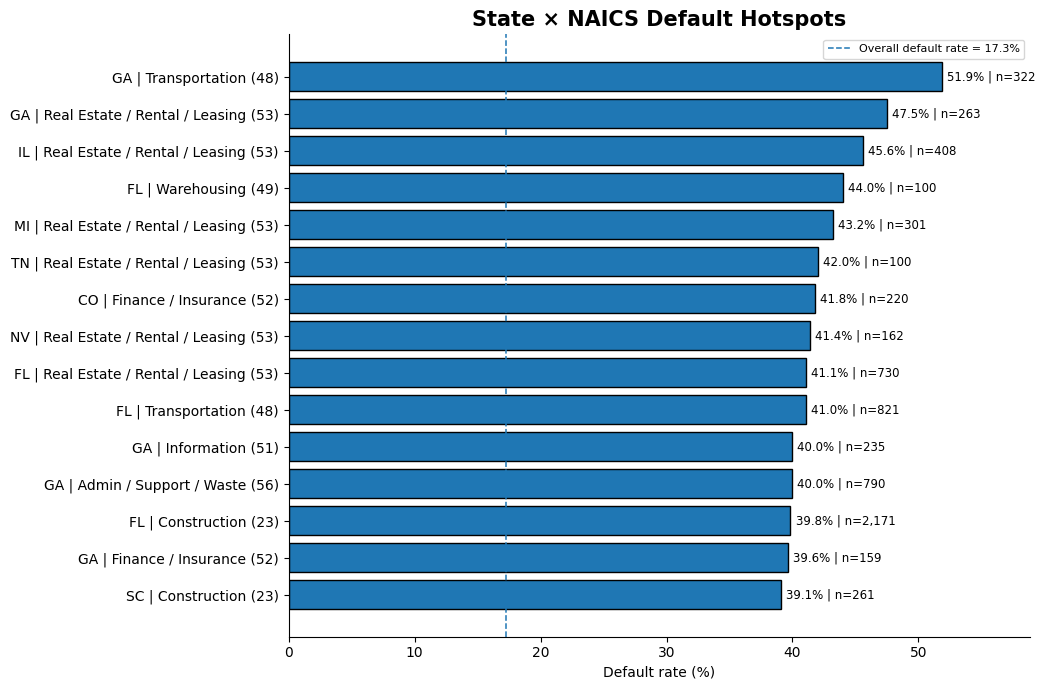


Saved:
/content/research_outputs/final_workflow_outputs/hai_an_external_eda/state_naics_default_hotspots_top15.csv
/content/research_outputs/final_workflow_outputs/hai_an_external_eda/state_naics_default_hotspots_top15.png


In [ ]:
# State × NAICS Default Hotspots Chart

SECTOR_NAME_HA = {
    "11": "Agriculture",
    "21": "Mining / Oil / Gas",
    "22": "Utilities",
    "23": "Construction",
    "31": "Manufacturing",
    "32": "Manufacturing",
    "33": "Manufacturing",
    "42": "Wholesale Trade",
    "44": "Retail Trade",
    "45": "Retail Trade",
    "48": "Transportation",
    "49": "Warehousing",
    "51": "Information",
    "52": "Finance / Insurance",
    "53": "Real Estate / Rental / Leasing",
    "54": "Professional Services",
    "56": "Admin / Support / Waste",
    "61": "Education",
    "62": "Health Care",
    "71": "Arts / Entertainment / Recreation",
    "72": "Accommodation / Food Services",
    "81": "Other Services",
    "92": "Public Administration",
    "00": "Unknown",
}

# Use a stricter minimum n so chart is not dominated by tiny cells
state_naics_hotspots_chart = (
    df_eda.groupby(["State", "NAICS_sector_str"])["y"]
    .agg(loan_count="count", default_rate="mean")
    .reset_index()
)

state_naics_hotspots_chart = state_naics_hotspots_chart[
    state_naics_hotspots_chart["loan_count"] >= 100
].copy()

state_naics_hotspots_chart["industry_name"] = (
    state_naics_hotspots_chart["NAICS_sector_str"]
    .map(SECTOR_NAME_HA)
    .fillna("Other")
)

state_naics_hotspots_chart["label"] = (
    state_naics_hotspots_chart["State"]
    + " | "
    + state_naics_hotspots_chart["industry_name"]
    + " ("
    + state_naics_hotspots_chart["NAICS_sector_str"].astype(str)
    + ")"
)

state_naics_hotspots_chart["default_rate_pct"] = (
    state_naics_hotspots_chart["default_rate"] * 100
)

state_naics_top15 = (
    state_naics_hotspots_chart
    .sort_values("default_rate", ascending=False)
    .head(15)
    .copy()
)

state_naics_top15.to_csv(
    OUT_HA / "state_naics_default_hotspots_top15.csv",
    index=False
)

print("\nTop 15 State × NAICS default hotspots:")
print(
    state_naics_top15[
        ["State", "NAICS_sector_str", "industry_name", "loan_count", "default_rate"]
    ].round(4).to_string(index=False)
)

# Plot
plot_df = state_naics_top15.sort_values("default_rate_pct", ascending=True)

fig, ax = plt.subplots(figsize=(10.5, 7))
bars = ax.barh(
    plot_df["label"],
    plot_df["default_rate_pct"],
    edgecolor="black",
    linewidth=1
)

overall_dr = df_eda["y"].mean() * 100
ax.axvline(
    overall_dr,
    linestyle="--",
    linewidth=1.1,
    label=f"Overall default rate = {overall_dr:.1f}%"
)

for bar, (_, r) in zip(bars, plot_df.iterrows()):
    ax.text(
        bar.get_width() + 0.4,
        bar.get_y() + bar.get_height() / 2,
        f"{r['default_rate_pct']:.1f}% | n={int(r['loan_count']):,}",
        va="center",
        fontsize=8.5
    )

ax.set_title("State × NAICS Default Hotspots", fontsize=15, fontweight="bold")
ax.set_xlabel("Default rate (%)")
ax.set_ylabel("")
ax.set_xlim(0, plot_df["default_rate_pct"].max() + 7)
ax.legend(frameon=True, fontsize=8)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig(
    OUT_HA / "state_naics_default_hotspots_top15.png",
    dpi=220,
    bbox_inches="tight"
)
plt.show()

print("\nSaved:")
print(OUT_HA / "state_naics_default_hotspots_top15.csv")
print(OUT_HA / "state_naics_default_hotspots_top15.png")

In [ ]:
qcew_cols = [c for c in df_eda.columns if c.startswith("qcew_")]
if qcew_cols:
    qcew_audit = []
    for col in qcew_cols:
        s = df_eda[col].dropna()
        if len(s) > 100:
            qcew_audit.append({
                "column": col,
                "count": len(s),
                "mean": s.mean(),
                "p5": s.quantile(0.05),
                "median": s.median(),
                "p95": s.quantile(0.95),
            })
    pd.DataFrame(qcew_audit).to_csv(OUT_HA / "qcew_column_summary.csv", index=False)
    print("Saved QCEW column summary.")


Saved QCEW column summary.


In [ ]:
if "state_hpi_negative_flag" in df_eda.columns:
    df_eda["_is_re"] = (df_eda["NAICS_sector_str"]=="53").astype(int)
    h2 = df_eda.groupby(["_is_re","state_hpi_negative_flag"])["y"].agg(["count","mean"]).round(4)
    h2.to_csv(OUT_HA/"real_estate_hpi_table.csv")
    print("Real estate x HPI:"); print(h2)
    df_eda["_is_const"] = (df_eda["NAICS_sector_str"]=="23").astype(int)
    h3 = df_eda.groupby(["_is_const","state_hpi_negative_flag"])["y"].agg(["count","mean"]).round(4)
    h3.to_csv(OUT_HA/"construction_hpi_table.csv")
    print("Construction x HPI:"); print(h3)
    ch = df_eda[(df_eda["_is_const"]==1)&(df_eda["state_hpi_negative_flag"]==1)]
    if len(ch)>50:
        chs = ch.groupby("State")["y"].agg(["count","mean"]).query("count>=20").sort_values("mean",ascending=False).round(4)
        chs.to_csv(OUT_HA/"construction_hpi_state_hotspots.csv")
    fig,ax=plt.subplots(figsize=(8,5))
    ax.bar(["No HPI/Not const","HPI/Not const","No HPI/Const","HPI+Const"],
           [df_eda[(df_eda["_is_const"]==0)&(df_eda["state_hpi_negative_flag"]==0)]["y"].mean()*100,
            df_eda[(df_eda["_is_const"]==0)&(df_eda["state_hpi_negative_flag"]==1)]["y"].mean()*100,
            df_eda[(df_eda["_is_const"]==1)&(df_eda["state_hpi_negative_flag"]==0)]["y"].mean()*100,
            df_eda[(df_eda["_is_const"]==1)&(df_eda["state_hpi_negative_flag"]==1)]["y"].mean()*100],
           color=["#2ecc71","#f39c12","#e67e22","#e74c3c"],edgecolor="black")
    ax.set_title("Construction x HPI Negative"); plt.xticks(rotation=15,ha="right")
    plt.tight_layout(); plt.savefig(OUT_HA/"construction_hpi.png",dpi=120); plt.close()

Real estate x HPI:
                                 count    mean
_is_re state_hpi_negative_flag                
0      0.0                      570274  0.1628
       1.0                      111776  0.2120
1      0.0                        8704  0.2723
       1.0                        2106  0.3585
Construction x HPI:
                                    count    mean
_is_const state_hpi_negative_flag                
0         0.0                      536484  0.1597
          1.0                      103820  0.2098
1         0.0                       42494  0.2247
          1.0                       10062  0.2649


In [ ]:
if "high_inflation_flag_lag1" in df_eda.columns:
    supply_naics = ["23","31","32","33","42","48","49"]
    df_eda["_supply"] = df_eda["NAICS_sector_str"].isin(supply_naics).astype(int)
    sc = df_eda.groupby(["_supply","high_inflation_flag_lag1"])["y"].agg(["count","mean"]).round(4)
    sc.to_csv(OUT_HA/"supply_chain_inflation_table.csv")
    print("Supply chain x inflation:"); print(sc)

Supply chain x inflation:
                                   count    mean
_supply high_inflation_flag_lag1                
0       0.0                       433840  0.1425
        1.0                        97303  0.2585
1       0.0                       126406  0.1789
        1.0                        35316  0.2860


In [ ]:
# QCEW / State-Industry Business Environment — Hai An


print("QCEW / STATE-INDUSTRY BUSINESS ENVIRONMENT — HAI AN")


# Make sure NAICS sector string exists and is clean
if "NAICS_sector_str" not in df_eda.columns:
    df_eda["NAICS_sector_str"] = (
        pd.to_numeric(df_eda["NAICS_sector"], errors="coerce")
        .astype("Int64")
        .astype(str)
    )

SECTOR_NAME_HA = {
    "11": "Agriculture",
    "21": "Mining / Oil / Gas",
    "22": "Utilities",
    "23": "Construction",
    "31": "Manufacturing",
    "32": "Manufacturing",
    "33": "Manufacturing",
    "42": "Wholesale Trade",
    "44": "Retail Trade",
    "45": "Retail Trade",
    "48": "Transportation",
    "49": "Warehousing",
    "51": "Information",
    "52": "Finance / Insurance",
    "53": "Real Estate / Rental / Leasing",
    "54": "Professional Services",
    "56": "Admin / Support / Waste",
    "61": "Education",
    "62": "Health Care",
    "71": "Arts / Entertainment / Recreation",
    "72": "Accommodation / Food Services",
    "81": "Other Services",
    "92": "Public Administration",
    "00": "Unknown",
}

df_eda["_ha_industry_name"] = df_eda["NAICS_sector_str"].map(SECTOR_NAME_HA).fillna("Other")


# ---------- Helper functions ----------

def _first_existing_col(candidates, data):
    """Return the first existing column name from a candidate list."""
    for c in candidates:
        if c in data.columns:
            return c
    return None


def _save_default_bar(table, x_col, y_col, n_col, title, filename, rotation=15):
    """Simple report-ready bar chart with default rate + sample size labels."""
    plot_df = table.copy()
    plot_df["_default_rate_pct"] = plot_df[y_col] * 100

    fig, ax = plt.subplots(figsize=(9, 5))
    bars = ax.bar(
        plot_df[x_col].astype(str),
        plot_df["_default_rate_pct"],
        edgecolor="black"
    )

    table_avg = (
        (plot_df[n_col] * plot_df[y_col]).sum()
        / plot_df[n_col].sum()
        * 100
    )

    ax.axhline(
        table_avg,
        linestyle="--",
        linewidth=1,
        label=f"Weighted average in this table = {table_avg:.1f}%"
    )

    for bar, (_, r) in zip(bars, plot_df.iterrows()):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.5,
            f"{r['_default_rate_pct']:.1f}%\nn={int(r[n_col]):,}",
            ha="center",
            va="bottom",
            fontsize=8
        )

    ax.set_title(title, fontweight="bold")
    ax.set_ylabel("Default rate (%)")
    ax.set_xlabel("")
    plt.xticks(rotation=rotation, ha="right")
    ax.legend(frameon=True, fontsize=8)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    plt.tight_layout()
    plt.savefig(OUT_HA / filename, dpi=200, bbox_inches="tight")
    plt.close()


# ---------- QCEW variable detection ----------
# Main workflow may contain either qcew_* columns or state_industry_* columns.
# This handles both.

employment_growth_col = _first_existing_col(
    [
        "state_industry_employment_growth",
        "qcew_oty_emplvl_pct_chg_lag1",
    ],
    df_eda
)

wage_growth_col = _first_existing_col(
    [
        "state_industry_wage_growth",
        "qcew_oty_wages_pct_chg_lag1",
    ],
    df_eda
)

establishment_growth_col = _first_existing_col(
    [
        "qcew_oty_estabs_pct_chg_lag1",
    ],
    df_eda
)

weekly_wage_col = _first_existing_col(
    [
        "qcew_annual_avg_wkly_wage_lag1",
    ],
    df_eda
)

density_flag_col = _first_existing_col(
    [
        "state_industry_density_flag",
    ],
    df_eda
)

contraction_flag_col = _first_existing_col(
    [
        "industry_contraction_flag",
    ],
    df_eda
)

qcew_cols = [
    c for c in [
        employment_growth_col,
        wage_growth_col,
        establishment_growth_col,
        weekly_wage_col,
        density_flag_col,
        contraction_flag_col,
        "state_industry_establishments" if "state_industry_establishments" in df_eda.columns else None,
    ]
    if c is not None
]

print("QCEW/state-industry columns detected:", qcew_cols)


# ---------- 1. QCEW variable summary ----------
qcew_summary_rows = []

for col in qcew_cols:
    s = df_eda[col].dropna()

    if len(s) > 0:
        qcew_summary_rows.append({
            "column": col,
            "non_missing_count": len(s),
            "missing_rate": df_eda[col].isna().mean(),
            "mean": s.mean(),
            "p5": s.quantile(0.05),
            "median": s.median(),
            "p95": s.quantile(0.95),
        })

qcew_summary = pd.DataFrame(qcew_summary_rows).round(4)
qcew_summary.to_csv(OUT_HA / "qcew_state_industry_variable_summary.csv", index=False)

print("\nQCEW/state-industry variable summary:")
print(qcew_summary.to_string(index=False))


# ---------- 2. Industry contraction flag ----------
# Prefer existing industry_contraction_flag.
# If missing, derive contraction from negative employment growth.

if contraction_flag_col is not None:
    df_eda["_qcew_contraction_flag"] = df_eda[contraction_flag_col].fillna(0).astype(int)
    contraction_source = contraction_flag_col

elif employment_growth_col is not None:
    df_eda["_qcew_contraction_flag"] = (df_eda[employment_growth_col] < 0).astype(int)
    contraction_source = f"{employment_growth_col} < 0"

else:
    contraction_source = None


if contraction_source is not None:
    qcew_contraction_table = (
        df_eda.groupby("_qcew_contraction_flag")
        .agg(
            loan_count=("y", "size"),
            default_rate=("y", "mean")
        )
        .reset_index()
    )

    qcew_contraction_table["condition"] = qcew_contraction_table["_qcew_contraction_flag"].map({
        0: "Industry not shrinking",
        1: "Industry shrinking"
    })

    qcew_contraction_table = qcew_contraction_table[
        ["condition", "loan_count", "default_rate"]
    ].round(4)

    qcew_contraction_table.to_csv(
        OUT_HA / "qcew_industry_contraction_table.csv",
        index=False
    )

    print("\nQCEW industry contraction table:")
    print(qcew_contraction_table.to_string(index=False))
    print("Contraction source:", contraction_source)

    _save_default_bar(
        qcew_contraction_table,
        x_col="condition",
        y_col="default_rate",
        n_col="loan_count",
        title="QCEW Industry Contraction and Default Risk",
        filename="qcew_industry_contraction.png",
        rotation=0
    )

else:
    print("\nSkipped QCEW industry contraction: no contraction or employment-growth column found.")


# ---------- 3. New business × low ecosystem density ----------
# Prefer state_industry_density_flag.
# If missing, use bottom-quartile establishment growth as a weaker ecosystem proxy.

if density_flag_col is not None:
    df_eda["_qcew_low_ecosystem_flag"] = df_eda[density_flag_col].fillna(0).astype(int)
    ecosystem_label = "Low state-industry density"
    ecosystem_source = density_flag_col

elif establishment_growth_col is not None:
    est_q25 = df_eda[establishment_growth_col].quantile(0.25)
    df_eda["_qcew_low_ecosystem_flag"] = (df_eda[establishment_growth_col] <= est_q25).astype(int)
    ecosystem_label = "Low/declining establishment growth"
    ecosystem_source = f"{establishment_growth_col} <= Q25"

else:
    ecosystem_source = None


if ecosystem_source is not None and "NewExist" in df_eda.columns:
    df_eda["_qcew_is_new_business"] = (df_eda["NewExist"] == 2).astype(int)

    qcew_density_table = (
        df_eda.groupby(["_qcew_is_new_business", "_qcew_low_ecosystem_flag"])
        .agg(
            loan_count=("y", "size"),
            default_rate=("y", "mean")
        )
        .reset_index()
    )

    qcew_density_table["segment"] = qcew_density_table.apply(
        lambda r:
        "Existing / normal ecosystem" if r["_qcew_is_new_business"] == 0 and r["_qcew_low_ecosystem_flag"] == 0 else
        f"Existing / {ecosystem_label}" if r["_qcew_is_new_business"] == 0 and r["_qcew_low_ecosystem_flag"] == 1 else
        "New / normal ecosystem" if r["_qcew_is_new_business"] == 1 and r["_qcew_low_ecosystem_flag"] == 0 else
        f"New / {ecosystem_label}",
        axis=1
    )

    qcew_density_table = qcew_density_table[
        ["segment", "loan_count", "default_rate"]
    ].round(4)

    qcew_density_table.to_csv(
        OUT_HA / "qcew_new_business_low_ecosystem_table.csv",
        index=False
    )

    print("\nQCEW new business × low ecosystem table:")
    print(qcew_density_table.to_string(index=False))
    print("Ecosystem source:", ecosystem_source)

    _save_default_bar(
        qcew_density_table,
        x_col="segment",
        y_col="default_rate",
        n_col="loan_count",
        title="New Business × QCEW Low Ecosystem Condition",
        filename="qcew_new_business_low_ecosystem.png",
        rotation=15
    )

else:
    print("\nSkipped new business × low ecosystem: no density/establishment proxy or NewExist missing.")


# ---------- 4. Wage pressure × labor-intensive sectors ----------
if wage_growth_col is not None:
    wage_p75 = df_eda[wage_growth_col].quantile(0.75)

    labor_intensive_naics = ["23", "44", "45", "56", "62", "72", "81"]

    df_eda["_qcew_labor_intensive"] = df_eda["NAICS_sector_str"].isin(labor_intensive_naics).astype(int)
    df_eda["_qcew_high_wage_growth"] = (df_eda[wage_growth_col] > wage_p75).astype(int)

    qcew_wage_table = (
        df_eda.groupby(["_qcew_labor_intensive", "_qcew_high_wage_growth"])
        .agg(
            loan_count=("y", "size"),
            default_rate=("y", "mean")
        )
        .reset_index()
    )

    qcew_wage_table["segment"] = qcew_wage_table.apply(
        lambda r:
        "Other sectors / normal wage growth" if r["_qcew_labor_intensive"] == 0 and r["_qcew_high_wage_growth"] == 0 else
        "Other sectors / high wage growth" if r["_qcew_labor_intensive"] == 0 and r["_qcew_high_wage_growth"] == 1 else
        "Labor-intensive / normal wage growth" if r["_qcew_labor_intensive"] == 1 and r["_qcew_high_wage_growth"] == 0 else
        "Labor-intensive / high wage growth",
        axis=1
    )

    qcew_wage_table = qcew_wage_table[
        ["segment", "loan_count", "default_rate"]
    ].round(4)

    qcew_wage_table.to_csv(
        OUT_HA / "qcew_wage_pressure_labor_intensive_table.csv",
        index=False
    )

    print("\nQCEW wage pressure × labor-intensive sectors:")
    print(qcew_wage_table.to_string(index=False))
    print(f"Wage source: {wage_growth_col}; high wage threshold = {wage_p75:.4f}")

    _save_default_bar(
        qcew_wage_table,
        x_col="segment",
        y_col="default_rate",
        n_col="loan_count",
        title="Labor-Intensive Sectors × QCEW High Wage Growth",
        filename="qcew_wage_pressure_labor_intensive.png",
        rotation=15
    )

else:
    print("\nSkipped wage pressure × labor-intensive sectors: no wage-growth column found.")


# ---------- 5. State × industry contraction hotspots ----------
if "_qcew_contraction_flag" in df_eda.columns and "State" in df_eda.columns:
    state_sector_raw = (
        df_eda.groupby(["State", "NAICS_sector_str", "_qcew_contraction_flag"])
        .agg(
            loan_count=("y", "size"),
            default_rate=("y", "mean")
        )
        .reset_index()
    )

    state_sector_lift = state_sector_raw.pivot(
        index=["State", "NAICS_sector_str"],
        columns="_qcew_contraction_flag",
        values=["loan_count", "default_rate"]
    )

    state_sector_lift.columns = [
        "count_not_shrinking", "count_shrinking",
        "rate_not_shrinking", "rate_shrinking"
    ]

    state_sector_lift = state_sector_lift.reset_index()
    state_sector_lift = state_sector_lift.dropna(
        subset=["rate_not_shrinking", "rate_shrinking"]
    )

    state_sector_lift = state_sector_lift[
        (state_sector_lift["count_not_shrinking"] >= 200) &
        (state_sector_lift["count_shrinking"] >= 200)
    ].copy()

    if len(state_sector_lift) > 0:
        state_sector_lift["industry_name"] = (
            state_sector_lift["NAICS_sector_str"]
            .map(SECTOR_NAME_HA)
            .fillna("Other")
        )

        state_sector_lift["contraction_lift_pp"] = (
            state_sector_lift["rate_shrinking"]
            - state_sector_lift["rate_not_shrinking"]
        ) * 100

        state_sector_lift = state_sector_lift.sort_values(
            "contraction_lift_pp",
            ascending=False
        )

        state_sector_lift.round(4).to_csv(
            OUT_HA / "qcew_state_industry_contraction_hotspots.csv",
            index=False
        )

        print("\nQCEW state × industry contraction hotspots:")
        print(
            state_sector_lift[
                [
                    "State",
                    "NAICS_sector_str",
                    "industry_name",
                    "count_not_shrinking",
                    "rate_not_shrinking",
                    "count_shrinking",
                    "rate_shrinking",
                    "contraction_lift_pp",
                ]
            ].head(20).to_string(index=False)
        )

        top_hotspots = state_sector_lift.head(15).copy()
        top_hotspots["label"] = (
            top_hotspots["State"]
            + " | "
            + top_hotspots["industry_name"]
            + " ("
            + top_hotspots["NAICS_sector_str"]
            + ")"
        )

        fig, ax = plt.subplots(figsize=(10, 6))
        bars = ax.barh(
            top_hotspots["label"][::-1],
            top_hotspots["contraction_lift_pp"][::-1],
            edgecolor="black"
        )

        for bar, (_, r) in zip(bars, top_hotspots[::-1].iterrows()):
            ax.text(
                bar.get_width() + 0.3,
                bar.get_y() + bar.get_height() / 2,
                f"+{r['contraction_lift_pp']:.1f} pp | n={int(r['count_shrinking']):,}",
                va="center",
                fontsize=8
            )

        ax.set_title("QCEW State × Industry Contraction Hotspots", fontweight="bold")
        ax.set_xlabel("Default-rate lift when industry is shrinking (percentage points)")
        ax.set_ylabel("")
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

        plt.tight_layout()
        plt.savefig(
            OUT_HA / "qcew_state_industry_contraction_hotspots.png",
            dpi=200,
            bbox_inches="tight"
        )
        plt.close()

    else:
        print("\nSkipped state × industry hotspot chart: not enough cells with both shrinking and non-shrinking counts >= 200.")

else:
    print("\nSkipped state × industry contraction hotspots: contraction flag or State missing.")


# ---------- 6. Industry stress stack count ----------
# This is a compact QCEW/business-environment summary feature for EDA.
# It stacks local industry contraction, low ecosystem, wage pressure, inflation, income decline, and oil shock if available.

stress_flag_cols = []

if "_qcew_contraction_flag" in df_eda.columns:
    df_eda["_qcew_stack_contraction"] = df_eda["_qcew_contraction_flag"].fillna(0).astype(int)
    stress_flag_cols.append("_qcew_stack_contraction")

if "_qcew_low_ecosystem_flag" in df_eda.columns:
    df_eda["_qcew_stack_low_ecosystem"] = df_eda["_qcew_low_ecosystem_flag"].fillna(0).astype(int)
    stress_flag_cols.append("_qcew_stack_low_ecosystem")

if "_qcew_high_wage_growth" in df_eda.columns:
    df_eda["_qcew_stack_wage_pressure"] = df_eda["_qcew_high_wage_growth"].fillna(0).astype(int)
    stress_flag_cols.append("_qcew_stack_wage_pressure")

if "high_inflation_flag_lag1" in df_eda.columns:
    df_eda["_qcew_stack_inflation"] = df_eda["high_inflation_flag_lag1"].fillna(0).astype(int)
    stress_flag_cols.append("_qcew_stack_inflation")

if "real_income_decline_flag_lag1" in df_eda.columns:
    df_eda["_qcew_stack_income_decline"] = df_eda["real_income_decline_flag_lag1"].fillna(0).astype(int)
    stress_flag_cols.append("_qcew_stack_income_decline")

if "oil_shock_flag_lag1" in df_eda.columns:
    df_eda["_qcew_stack_oil_shock"] = df_eda["oil_shock_flag_lag1"].fillna(0).astype(int)
    stress_flag_cols.append("_qcew_stack_oil_shock")


if stress_flag_cols:
    df_eda["_qcew_industry_stress_stack_count"] = df_eda[stress_flag_cols].sum(axis=1)

    qcew_stack_table = (
        df_eda.groupby("_qcew_industry_stress_stack_count")
        .agg(
            loan_count=("y", "size"),
            default_count=("y", "sum"),
            default_rate=("y", "mean")
        )
        .reset_index()
    )

    qcew_stack_table = qcew_stack_table.rename(
        columns={"_qcew_industry_stress_stack_count": "industry_stress_stack_count"}
    ).round(4)

    qcew_stack_table.to_csv(
        OUT_HA / "qcew_industry_stress_stack_table.csv",
        index=False
    )

    print("\nQCEW / business-environment stress stack table:")
    print(qcew_stack_table.to_string(index=False))
    print("Stress flags used:", stress_flag_cols)

    fig, ax = plt.subplots(figsize=(8, 5))
    bars = ax.bar(
        qcew_stack_table["industry_stress_stack_count"].astype(str),
        qcew_stack_table["default_rate"] * 100,
        edgecolor="black"
    )

    table_avg = (
        (qcew_stack_table["loan_count"] * qcew_stack_table["default_rate"]).sum()
        / qcew_stack_table["loan_count"].sum()
        * 100
    )

    ax.axhline(
        table_avg,
        linestyle="--",
        linewidth=1,
        label=f"Weighted average in this table = {table_avg:.1f}%"
    )

    for bar, (_, r) in zip(bars, qcew_stack_table.iterrows()):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.4,
            f"{r['default_rate']*100:.1f}%\nn={int(r['loan_count']):,}",
            ha="center",
            va="bottom",
            fontsize=8
        )

    ax.set_title("Default Rate by Industry Stress Stack Count", fontweight="bold")
    ax.set_xlabel("Number of stacked industry/business-environment stressors")
    ax.set_ylabel("Default rate (%)")
    ax.legend(frameon=True, fontsize=8)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    plt.tight_layout()
    plt.savefig(
        OUT_HA / "qcew_industry_stress_stack.png",
        dpi=200,
        bbox_inches="tight"
    )
    plt.close()

else:
    print("\nSkipped industry stress stack count: no stress flags available.")


# ---------- 7. Clean temporary QCEW columns ----------
qcew_temp_cols = [
    c for c in df_eda.columns
    if c.startswith("_qcew_") or c.startswith("_ha_")
]

df_eda.drop(columns=qcew_temp_cols, errors="ignore", inplace=True)

print("\nQCEW / state-industry EDA done. Outputs saved to:", OUT_HA)

In [ ]:
df_eda.drop(columns=["_is_re","_is_const","_supply"],errors="ignore",inplace=True)
print("Hai An external EDA done.")

Hai An external EDA done.




# External EDA — Huyen Anh - Geography / Disaster / Tourism



You cover: geography, FEMA disaster exposure, tourism vulnerability, coastal exposure, and hurricane-sensitive interactions.

Collect: state default-rate table, tourism industry baseline table, coastal-state table, FEMA disaster-type table, era-split disaster table if useful, tourism × hurricane table, coastal × hurricane table, and disaster-sensitive × hurricane table.

Write: what pattern did you find? Which disaster signals are strong enough to keep as features, and which are only report nuance?

## 10. External EDA: Huyen Anh — Disaster / Housing / External Shocks

In [ ]:
OUT_HUY = FINAL_OUT / "huyen_anh_external_eda"; OUT_HUY.mkdir(parents=True, exist_ok=True)

In [ ]:
if "NAICS_sector_str" not in df_eda.columns:
    df_eda["NAICS_sector_str"] = pd.to_numeric(df_eda["NAICS_sector"],errors="coerce").astype("Int64").astype(str)

In [ ]:
print("FEMA columns:", [c for c in df_eda.columns if c.startswith("fema_")])


FEMA columns: ['fema_hurricane_12m', 'fema_flood_12m', 'fema_fire_12m', 'fema_severe_storm_12m', 'fema_tornado_12m', 'fema_drought_12m', 'fema_winter_event_12m', 'fema_earthquake_12m', 'fema_DR_12m', 'fema_EM_12m', 'fema_FM_12m', 'fema_hurricane_count_24m', 'fema_flood_count_24m', 'fema_fire_count_24m', 'fema_severe_storm_count_24m', 'fema_tornado_count_24m', 'fema_drought_count_24m', 'fema_winter_event_count_24m', 'fema_earthquake_count_24m', 'fema_DR_count_24m', 'fema_EM_count_24m', 'fema_FM_count_24m']


### Huyen Anh Baseline Clues


- tourism industry baseline
- coastal state baseline
- disaster-sensitive sector baseline
- state default-rate baseline


In [ ]:
fema_12m = [c for c in df_eda.columns if c.startswith("fema_") and c.endswith("_12m")]
fema_rows = []
for col in fema_12m:
    e0=df_eda[df_eda[col]==0]; e1=df_eda[df_eda[col]==1]
    if len(e1)<20: continue
    fema_rows.append({"variable":col,"unexposed_n":len(e0),"unexposed_dr":e0["y"].mean(),
                       "exposed_n":len(e1),"exposed_dr":e1["y"].mean(),
                       "delta_pp":round((e1["y"].mean()-e0["y"].mean())*100,2)})
if fema_rows:
    fema_df = pd.DataFrame(fema_rows).sort_values("delta_pp",ascending=False)
    fema_df.to_csv(OUT_HUY/"fema_disaster_type_default_rates.csv",index=False)
    print("\nFEMA disaster types:"); print(fema_df.to_string(index=False))
    fig,ax=plt.subplots(figsize=(10,5))
    x=np.arange(len(fema_df)); w=0.35
    ax.bar(x-w/2,fema_df["unexposed_dr"]*100,w,label="Unexposed",color="#2ecc71",edgecolor="black")
    ax.bar(x+w/2,fema_df["exposed_dr"]*100,w,label="Exposed",color="#e74c3c",edgecolor="black")
    ax.set_xticks(x); ax.set_xticklabels([c.replace("fema_","").replace("_12m","") for c in fema_df["variable"]],rotation=45,ha="right")
    ax.set_title("Default Rate by FEMA Disaster Type (12m)"); ax.set_ylabel("Default Rate (%)"); ax.legend()
    plt.tight_layout(); plt.savefig(OUT_HUY/"fema_disaster_type_default_rates.png",dpi=120); plt.close()
else:
    empty_fema = pd.DataFrame(columns=["variable","unexposed_n","unexposed_dr","exposed_n","exposed_dr","delta_pp"])
    empty_fema.to_csv(OUT_HUY/"fema_disaster_type_default_rates.csv",index=False)
    print("\nFEMA disaster types: no type has enough exposed observations.")


FEMA disaster types:
             variable  unexposed_n  unexposed_dr  exposed_n  exposed_dr  delta_pp
   fema_hurricane_12m       586629      0.155364     106236    0.268544     11.32
          fema_FM_12m       506873      0.148507     185992    0.238698      9.02
          fema_EM_12m       505118      0.149919     187747    0.234054      8.41
        fema_fire_12m       483157      0.153190     209708    0.217707      6.45
fema_severe_storm_12m       381958      0.148561     310907    0.202395      5.38
          fema_DR_12m       233285      0.148025     459580    0.185252      3.72
fema_winter_event_12m       580807      0.168164     112058    0.196318      2.82
  fema_earthquake_12m       667013      0.175123      25852    0.110668     -6.45
     fema_tornado_12m       669759      0.174891      23106    0.109712     -6.52
       fema_flood_12m       619755      0.184107      73110    0.076173    -10.79
     fema_drought_12m       690187      0.173265       2678    0.031740    -

Tourism

In [ ]:
df_eda["tourism_industry_flag"] = df_eda["NAICS_sector_str"].isin(["44","45","71","72"]).astype(int)
tr = df_eda.groupby("tourism_industry_flag")["y"].agg(n="count",dr="mean").round(4)
tr.to_csv(OUT_HUY/"tourism_industry_default_rate.csv"); print("Tourism:"); print(tr)

Tourism:
                            n      dr
tourism_industry_flag                
0                      527411  0.1566
1                      165454  0.2240


Coastal

In [ ]:
coastal = ["AL","AK","CA","CT","DE","FL","GA","HI","LA","ME","MD","MA","MS","NH","NJ","NY","NC","OR","RI","SC","TX","VA","WA"]
df_eda["coastal_state_flag"] = df_eda["State"].isin(coastal).astype(int)
cs = df_eda.groupby("coastal_state_flag")["y"].agg(n="count",dr="mean").round(4)
cs.to_csv(OUT_HUY/"coastal_state_default_rates.csv")

In [ ]:
disaster_sensitive_codes = ["23", "44", "45", "48", "49", "51", "71", "72"]
df_eda["disaster_sensitive_sector_flag"] = df_eda["NAICS_sector_str"].isin(disaster_sensitive_codes).astype(int)

ds = df_eda.groupby("disaster_sensitive_sector_flag")["y"].agg(n="count", dr="mean").round(4)
ds.to_csv(OUT_HUY / "disaster_sensitive_sector_default_rates.csv")
print("Disaster-sensitive sector baseline:")
print(ds)

Disaster-sensitive sector baseline:
                                     n      dr
disaster_sensitive_sector_flag                
0                               447885  0.1414
1                               244980  0.2300


In [ ]:
state_base = (
    df_eda.groupby("State")["y"]
    .agg(n="count", dr="mean")
    .query("n >= 100")
    .sort_values("dr", ascending=False)
    .round(4)
)
state_base.to_csv(OUT_HUY / "state_default_rate_table.csv")
print("Saved state default-rate table.")


Saved state default-rate table.


In [ ]:
print("FEMA columns:", [c for c in df_eda.columns if c.startswith("fema_")])


FEMA columns: ['fema_hurricane_12m', 'fema_flood_12m', 'fema_fire_12m', 'fema_severe_storm_12m', 'fema_tornado_12m', 'fema_drought_12m', 'fema_winter_event_12m', 'fema_earthquake_12m', 'fema_DR_12m', 'fema_EM_12m', 'fema_FM_12m', 'fema_hurricane_count_24m', 'fema_flood_count_24m', 'fema_fire_count_24m', 'fema_severe_storm_count_24m', 'fema_tornado_count_24m', 'fema_drought_count_24m', 'fema_winter_event_count_24m', 'fema_earthquake_count_24m', 'fema_DR_count_24m', 'fema_EM_count_24m', 'fema_FM_count_24m']


In [ ]:
fema_12m = [c for c in df_eda.columns if c.startswith("fema_") and c.endswith("_12m")]
fema_rows = []
for col in fema_12m:
    e0=df_eda[df_eda[col]==0]; e1=df_eda[df_eda[col]==1]
    if len(e1)<20: continue
    fema_rows.append({"variable":col,"unexposed_n":len(e0),"unexposed_dr":e0["y"].mean(),
                       "exposed_n":len(e1),"exposed_dr":e1["y"].mean(),
                       "delta_pp":round((e1["y"].mean()-e0["y"].mean())*100,2)})
if fema_rows:
    fema_df = pd.DataFrame(fema_rows).sort_values("delta_pp",ascending=False)
    fema_df.to_csv(OUT_HUY/"fema_disaster_type_default_rates.csv",index=False)
    print("\nFEMA disaster types:"); print(fema_df.to_string(index=False))
    fig,ax=plt.subplots(figsize=(10,5))
    x=np.arange(len(fema_df)); w=0.35
    ax.bar(x-w/2,fema_df["unexposed_dr"]*100,w,label="Unexposed",color="#2ecc71",edgecolor="black")
    ax.bar(x+w/2,fema_df["exposed_dr"]*100,w,label="Exposed",color="#e74c3c",edgecolor="black")
    ax.set_xticks(x); ax.set_xticklabels([c.replace("fema_","").replace("_12m","") for c in fema_df["variable"]],rotation=45,ha="right")
    ax.set_title("Default Rate by FEMA Disaster Type (12m)"); ax.set_ylabel("Default Rate (%)"); ax.legend()
    plt.tight_layout(); plt.savefig(OUT_HUY/"fema_disaster_type_default_rates.png",dpi=120); plt.close()
else:
    empty_fema = pd.DataFrame(columns=["variable","unexposed_n","unexposed_dr","exposed_n","exposed_dr","delta_pp"])
    empty_fema.to_csv(OUT_HUY/"fema_disaster_type_default_rates.csv",index=False)
    print("\nFEMA disaster types: no type has enough exposed observations.")


FEMA disaster types:
             variable  unexposed_n  unexposed_dr  exposed_n  exposed_dr  delta_pp
   fema_hurricane_12m       586629      0.155364     106236    0.268544     11.32
          fema_FM_12m       506873      0.148507     185992    0.238698      9.02
          fema_EM_12m       505118      0.149919     187747    0.234054      8.41
        fema_fire_12m       483157      0.153190     209708    0.217707      6.45
fema_severe_storm_12m       381958      0.148561     310907    0.202395      5.38
          fema_DR_12m       233285      0.148025     459580    0.185252      3.72
fema_winter_event_12m       580807      0.168164     112058    0.196318      2.82
  fema_earthquake_12m       667013      0.175123      25852    0.110668     -6.45
     fema_tornado_12m       669759      0.174891      23106    0.109712     -6.52
       fema_flood_12m       619755      0.184107      73110    0.076173    -10.79
     fema_drought_12m       690187      0.173265       2678    0.031740    -

Era-split disasters

In [ ]:
era_split_cols = [c for c in ["fema_hurricane_12m","fema_fire_12m","fema_flood_12m","fema_severe_storm_12m","state_hpi_negative_flag"] if c in df_eda.columns]
era_rows = []
for col in era_split_cols:
    for e in ["pre","crisis","post"]:
        s=df_eda[df_eda["era"]==e]
        for v in [0,1]:
            seg=s[s[col]==v]
            if len(seg)>30: era_rows.append({"variable":col,"era":e,"exposed":v,"n":len(seg),"dr":seg["y"].mean()})
if era_rows: pd.DataFrame(era_rows).to_csv(OUT_HUY/"era_split_disaster_default_rates.csv",index=False)

Hurricane by NAICS

In [ ]:
if "fema_hurricane_12m" in df_eda.columns:
    h_naics = df_eda.groupby("NAICS_sector_str").apply(lambda g: pd.Series({
        "total_n":len(g),"hurr_n":(g["fema_hurricane_12m"]==1).sum(),
        "no_hurr_dr":g[g["fema_hurricane_12m"]==0]["y"].mean(),
        "hurr_dr":g[g["fema_hurricane_12m"]==1]["y"].mean() if (g["fema_hurricane_12m"]==1).sum()>=20 else np.nan})).reset_index()
    h_naics["delta_pp"] = ((h_naics["hurr_dr"]-h_naics["no_hurr_dr"])*100).round(2)
    h_naics.dropna(subset=["hurr_dr"]).sort_values("delta_pp",ascending=False).to_csv(OUT_HUY/"hurricane_by_naics_delta.csv",index=False)

Hurricane by state

In [ ]:
# Hurricane by state
if "fema_hurricane_12m" in df_eda.columns:
    h_state = df_eda.groupby("State").apply(lambda g: pd.Series({
        "total_n": len(g),
        "hurr_n": (g["fema_hurricane_12m"]==1).sum(),
        "no_hurr_dr": g[g["fema_hurricane_12m"]==0]["y"].mean(),
        "hurr_dr": g[g["fema_hurricane_12m"]==1]["y"].mean()
                   if (g["fema_hurricane_12m"]==1).sum()>=20 else np.nan
    })).reset_index()
    h_state["delta_pp"] = ((h_state["hurr_dr"] - h_state["no_hurr_dr"])*100).round(2)
    h_state = h_state.dropna(subset=["hurr_dr"]).sort_values("delta_pp", ascending=False)
    print("=== Hurricane by state (top 15) ===")
    print(h_state.head(15))
    h_state.to_csv(OUT_HUY/"hurricane_by_state_delta.csv", index=False)

=== Hurricane by state (top 15) ===
   State   total_n  hurr_n  no_hurr_dr   hurr_dr  delta_pp
4     CA  101093.0  8309.0    0.166139  0.411843     24.57
33    NV    6179.0   599.0    0.211111  0.449082     23.80
3     AZ   13810.0  1212.0    0.183521  0.418317     23.48
22    MI   15981.0  2091.0    0.195536  0.428025     23.25
42    TN    7129.0   768.0    0.188178  0.399740     21.16
14    IL   22906.0  2560.0    0.194338  0.403906     20.96
12    IA    8885.0   466.0    0.093123  0.255365     16.22
24    MO   15196.0  1114.0    0.132581  0.292639     16.01
16    KS    8425.0   524.0    0.097962  0.255725     15.78
36    OK    7680.0   536.0    0.137878  0.294776     15.69
15    IN   10856.0  1354.0    0.154810  0.305022     15.02
39    RI    7032.0   584.0    0.100031  0.248288     14.83
49    WV    2545.0   299.0    0.130009  0.264214     13.42
23    MN   18976.0  1419.0    0.108219  0.238196     13.00
2     AR    4959.0   414.0    0.150715  0.277778     12.71


Fire by NAICS

In [ ]:
# Fire by NAICS sector
if "fema_fire_12m" in df_eda.columns:
    f_naics = df_eda.groupby("NAICS_sector_str").apply(lambda g: pd.Series({
        "total_n": len(g),
        "fire_n": (g["fema_fire_12m"]==1).sum(),
        "no_fire_dr": g[g["fema_fire_12m"]==0]["y"].mean(),
        "fire_dr": g[g["fema_fire_12m"]==1]["y"].mean()
                   if (g["fema_fire_12m"]==1).sum()>=20 else np.nan
    })).reset_index()
    f_naics["delta_pp"] = ((f_naics["fire_dr"] - f_naics["no_fire_dr"])*100).round(2)
    f_naics = f_naics.dropna(subset=["fire_dr"]).sort_values("delta_pp", ascending=False)
    print("=== Fire by NAICS sector (top 15) ===")
    print(f_naics.head(15))
    f_naics.to_csv(OUT_HUY/"fire_by_naics_delta.csv", index=False)

=== Fire by NAICS sector (top 15) ===
   NAICS_sector_str  total_n   fire_n  no_fire_dr   fire_dr  delta_pp
24               92    179.0     48.0    0.145038  0.270833     12.58
14               52   7552.0   3060.0    0.243767  0.342157      9.84
18               56  25928.0   8095.0    0.208490  0.299321      9.08
21               71  11554.0   3302.0    0.182380  0.264688      8.23
11               48  16125.0   4754.0    0.247735  0.326672      7.89
3                22    514.0    162.0    0.113636  0.191358      7.77
15               53  10812.0   3939.0    0.261312  0.337395      7.61
16               54  53926.0  18290.0    0.166657  0.240842      7.42
10               45  33339.0   9566.0    0.214739  0.286536      7.18
13               51   9073.0   3129.0    0.227456  0.298818      7.14
4                23  52558.0  17561.0    0.209018  0.278914      6.99
6                32  13931.0   4238.0    0.145156  0.212600      6.74
12               49   1770.0    562.0    0.214404  0

Fire by state

In [ ]:
if "fema_fire_12m" in df_eda.columns:
    f_state = df_eda.groupby("State").apply(lambda g: pd.Series({
        "total_n":len(g),"fire_n":(g["fema_fire_12m"]==1).sum(),
        "no_fire_dr":g[g["fema_fire_12m"]==0]["y"].mean(),
        "fire_dr":g[g["fema_fire_12m"]==1]["y"].mean() if (g["fema_fire_12m"]==1).sum()>=20 else np.nan})).reset_index()
    f_state["delta_pp"] = ((f_state["fire_dr"]-f_state["no_fire_dr"])*100).round(2)
    f_state.dropna(subset=["fire_dr"]).sort_values("delta_pp",ascending=False).to_csv(OUT_HUY/"fire_by_state_delta.csv",index=False)

Severe storm by NAICS

In [ ]:
# Severe storm by NAICS sector
if "fema_severe_storm_12m" in df_eda.columns:
    ss_naics = df_eda.groupby("NAICS_sector_str").apply(lambda g: pd.Series({
        "total_n": len(g),
        "storm_n": (g["fema_severe_storm_12m"]==1).sum(),
        "no_storm_dr": g[g["fema_severe_storm_12m"]==0]["y"].mean(),
        "storm_dr": g[g["fema_severe_storm_12m"]==1]["y"].mean()
                    if (g["fema_severe_storm_12m"]==1).sum()>=20 else np.nan
    })).reset_index()
    ss_naics["delta_pp"] = ((ss_naics["storm_dr"] - ss_naics["no_storm_dr"])*100).round(2)
    ss_naics = ss_naics.dropna(subset=["storm_dr"]).sort_values("delta_pp", ascending=False)
    print("=== Severe storm by NAICS sector (top 15) ===")
    print(ss_naics.head(15))
    ss_naics.to_csv(OUT_HUY/"severe_storm_by_naics_delta.csv", index=False)

=== Severe storm by NAICS sector (top 15) ===
   NAICS_sector_str  total_n  storm_n  no_storm_dr  storm_dr  delta_pp
17               55    204.0     89.0     0.069565  0.168539      9.90
24               92    179.0     77.0     0.137255  0.233766      9.65
15               53  10812.0   5472.0     0.252622  0.324561      7.19
8                42  38191.0  17350.0     0.166115  0.231816      6.57
4                23  52558.0  25296.0     0.201232  0.265931      6.47
5                31   9204.0   4157.0     0.169804  0.231176      6.14
3                22    514.0    250.0     0.109848  0.168000      5.82
10               45  33339.0  15423.0     0.209422  0.265448      5.60
23               81  56768.0  26502.0     0.171579  0.225568      5.40
9                44  66629.0  30847.0     0.199877  0.253055      5.32
14               52   7552.0   3762.0     0.258047  0.309410      5.14
19               61   5155.0   2561.0     0.221280  0.272550      5.13
21               71  11554.0   

Severe storm by state

In [ ]:
# Severe storm by state
if "fema_severe_storm_12m" in df_eda.columns:
    ss_state = df_eda.groupby("State").apply(lambda g: pd.Series({
        "total_n": len(g),
        "storm_n": (g["fema_severe_storm_12m"]==1).sum(),
        "no_storm_dr": g[g["fema_severe_storm_12m"]==0]["y"].mean(),
        "storm_dr": g[g["fema_severe_storm_12m"]==1]["y"].mean()
                    if (g["fema_severe_storm_12m"]==1).sum()>=20 else np.nan
    })).reset_index()
    ss_state["delta_pp"] = ((ss_state["storm_dr"] - ss_state["no_storm_dr"])*100).round(2)
    ss_state = ss_state.dropna(subset=["storm_dr"]).sort_values("delta_pp", ascending=False)
    print("=== Severe storm by state (top 15) ===")
    print(ss_state.head(15))
    ss_state.to_csv(OUT_HUY/"severe_storm_by_state_delta.csv", index=False)

=== Severe storm by state (top 15) ===
   State   total_n  storm_n  no_storm_dr  storm_dr  delta_pp
6     CT    9630.0   1342.0     0.109435  0.289121     17.97
33    NV    6179.0   1888.0     0.181077  0.354873     17.38
3     AZ   13810.0   4434.0     0.154330  0.309427     15.51
34    NY   44411.0  27246.0     0.107661  0.252918     14.53
31    NJ   18853.0   9617.0     0.130251  0.259020     12.88
37    OR    8557.0   4202.0     0.088634  0.217277     12.86
16    KS    8425.0   3833.0     0.051394  0.175320     12.39
47    WA   17921.0   8869.0     0.081198  0.199910     11.87
39    RI    7032.0    261.0     0.108108  0.222222     11.41
20    MD   10347.0   2445.0     0.172615  0.283845     11.12
4     CA  101093.0  35388.0     0.151419  0.251159      9.97
29    NE    4855.0   2976.0     0.050027  0.145833      9.58
5     CO   16104.0   3149.0     0.158549  0.247698      8.91
11    HI    2802.0    861.0     0.125708  0.213705      8.80
19    MA   19414.0   6230.0     0.098529  0.18

FEMA Look-back Window

In [ ]:
lookback_cols = [c for c in df_eda.columns
                 if "disaster_last" in c or "disaster_count" in c]
print("Available lookback columns:", lookback_cols)

for col in lookback_cols:
    if "count" in col:
        df_eda["_flag"] = (df_eda[col] > 0).astype(int)
        tbl = df_eda.groupby("_flag")["y"].agg(["count","mean"]).round(4)
        print(f"\n{col} > 0:")
        print(tbl)
    else:
        tbl = df_eda.groupby(col)["y"].agg(["count","mean"]).round(4)
        print(f"\n{col}:")
        print(tbl)

Available lookback columns: ['disaster_last_6m', 'disaster_last_12m', 'disaster_count_24m']

disaster_last_6m:
                   count    mean
disaster_last_6m                
0                 283671  0.1398
1                 409194  0.1956

disaster_last_12m:
                    count    mean
disaster_last_12m                
0                  131941  0.1205
1                  560924  0.1850

disaster_count_24m > 0:
        count    mean
_flag                
0       41885  0.0787
1      650980  0.1788


Costal state exposure

In [ ]:
# Coastal state exposure — by era
print("=== Coastal state by era ===")
print(df_eda.groupby(["coastal_state_flag","era"])["y"].agg(["count","mean"]).round(4))

# Coastal state — by disaster exposure
print("\n=== Coastal state × any disaster ===")
if "disaster_last_12m" in df_eda.columns:
    print(df_eda.groupby(["coastal_state_flag","disaster_last_12m"])["y"].agg(["count","mean"]).round(4))

=== Coastal state by era ===
                            count    mean
coastal_state_flag era                   
0                  crisis   46832  0.2816
                   post      6172  0.0617
                   pre     233190  0.1339
1                  crisis   60328  0.3967
                   post      7080  0.0640
                   pre     339263  0.1489

=== Coastal state × any disaster ===
                                       count    mean
coastal_state_flag disaster_last_12m                
0                  0                   72159  0.1097
                   1                  214035  0.1723
1                  0                   59782  0.1335
                   1                  346889  0.1929


Tourism industry exposure

In [ ]:
# Tourism industry exposure — by era
print("=== Tourism industry by era ===")
print(df_eda.groupby(["tourism_industry_flag","era"])["y"].agg(["count","mean"]).round(4))

# Tourism — by disaster exposure
print("\n=== Tourism × any disaster ===")
if "disaster_last_12m" in df_eda.columns:
    print(df_eda.groupby(["tourism_industry_flag","disaster_last_12m"])["y"].agg(["count","mean"]).round(4))

=== Tourism industry by era ===
                               count    mean
tourism_industry_flag era                   
0                     crisis   76517  0.3369
                      post      9957  0.0533
                      pre     440937  0.1277
1                     crisis   30643  0.3701
                      post      3295  0.0920
                      pre     131516  0.1932

=== Tourism × any disaster ===
                                          count    mean
tourism_industry_flag disaster_last_12m                
0                     0                  104113  0.1059
                      1                  423298  0.1691
1                     0                   27828  0.1751
                      1                  137626  0.2338


Interaction terms

In [ ]:
# 1. Tourism x hurricane interaction
print("=== Tourism x Hurricane ===")
print(df_eda.groupby(["tourism_industry_flag","fema_hurricane_12m"])["y"].agg(["count","mean"]).round(4))

# 2. Coastal x hurricane interaction
print("\n=== Coastal x Hurricane ===")
print(df_eda.groupby(["coastal_state_flag","fema_hurricane_12m"])["y"].agg(["count","mean"]).round(4))

# 3. Disaster sensitive x hurricane
print("\n=== Disaster Sensitive x Hurricane ===")
print(df_eda.groupby(["disaster_sensitive_sector_flag","fema_hurricane_12m"])["y"].agg(["count","mean"]).round(4))

=== Tourism x Hurricane ===
                                           count    mean
tourism_industry_flag fema_hurricane_12m                
0                     0                   449918  0.1401
                      1                    77493  0.2526
1                     0                   136711  0.2055
                      1                    28743  0.3116

=== Coastal x Hurricane ===
                                        count    mean
coastal_state_flag fema_hurricane_12m                
0                  0                   259759  0.1429
                   1                    26435  0.2900
1                  0                   326870  0.1653
                   1                    79801  0.2614

=== Disaster Sensitive x Hurricane ===
                                                    count    mean
disaster_sensitive_sector_flag fema_hurricane_12m                
0                              0                   385693  0.1265
                               1       

In [ ]:
print(f"\nHuyen Anh external EDA complete. Outputs: {OUT_HUY}")


Huyen Anh external EDA complete. Outputs: /content/research_outputs/final_workflow_outputs/huyen_anh_external_eda


## 11. Modeling data — full development set

In [ ]:
df_model = df_dev.copy()

In [ ]:
print(f"Modeling data: {len(df_model):,}, DR={df_model['y'].mean():.4f}")
for e in ["pre", "crisis", "post"]:
    era_slice = df_model[df_model["era"] == e]
    print(f"  {e}: {len(era_slice):,}, DR={era_slice['y'].mean():.4f}")

Modeling data: 692,865, DR=0.1727
  pre: 572,453, DR=0.1427
  crisis: 107,160, DR=0.3464
  post: 13,252, DR=0.0629


df_model: full development set used for train/validation. FEATURE_MODE: "sba_only" or "sba_plus_external".



# Feature Engineering Sandbox



Add model features from your EDA here. Rules:



1. Create columns on `df_model`. 2. Append names to `ADDED_NUMERIC_FEATURES` or `ADDED_CATEGORICAL_FEATURES`. 3. Add a row to `FEATURE_NOTES` with feature, your name, one-sentence business reason. 4. Do not modify y, df_final_test, the split, the profit function, or threshold tuning.



Your feature is not report-ready unless you can explain it in one sentence.



Important: if you create a new feature here, also recreate it inside `add_engineered_features_for_model(data)`. Otherwise the final test set will not have that feature.

## 12. Feature Engineering Sandbox

In [ ]:
ADDED_NUMERIC_FEATURES = []
ADDED_CATEGORICAL_FEATURES = []
FEATURE_NOTES = []
EXPERIMENT_LOG = []

---- Hai An — industry and housing features ----

In [ ]:
if "NAICS_sector_str" in df_model.columns and "state_hpi_negative_flag" in df_model.columns:
    is_re = df_model["NAICS_sector_str"] == "53"
    is_const = df_model["NAICS_sector_str"] == "23"
    hpi_down = df_model["state_hpi_negative_flag"] == 1
    df_model["real_estate_industry_hpi"] = (is_re & hpi_down).astype(int)
    df_model["construction_hpi"] = (is_const & hpi_down).astype(int)
    ADDED_NUMERIC_FEATURES.extend(["real_estate_industry_hpi", "construction_hpi"])
    FEATURE_NOTES.append({"feature":"real_estate_industry_hpi","owner":"Hai An","reason":"Real estate businesses may be riskier when local housing prices fall"})
    FEATURE_NOTES.append({"feature":"construction_hpi","owner":"Hai An","reason":"Construction firms may face demand drop when HPI is negative"})

In [ ]:
if "high_inflation_flag_lag1" in df_model.columns and "NAICS_sector_str" in df_model.columns:
    supply_codes = ["23","31","32","33","42","48","49"]
    df_model["supply_chain_inflation"] = (df_model["NAICS_sector_str"].isin(supply_codes) & (df_model["high_inflation_flag_lag1"]==1)).astype(int)
    ADDED_NUMERIC_FEATURES.append("supply_chain_inflation")
    FEATURE_NOTES.append({"feature":"supply_chain_inflation","owner":"Hai An","reason":"Supply chain sectors may struggle during high inflation periods"})

---- Hai Anh features ----

In [ ]:
if "high_inflation_flag_lag1" in df_model.columns and "NoEmp" in df_model.columns:
    df_model["inflation_micro_business"] = (
        (df_model["high_inflation_flag_lag1"] == 1) & (df_model["NoEmp"] <= 5)
    ).astype(int)
    ADDED_NUMERIC_FEATURES.append("inflation_micro_business")
    FEATURE_NOTES.append({"feature":"inflation_micro_business","owner":"Hai Anh","reason":"Small firms may be more exposed when inflation raises operating costs"})

In [ ]:
if "oil_shock_flag_lag1" in df_model.columns and "NAICS_sector_str" in df_model.columns:
    supply_codes = ["23","31","32","33","42","48","49"]
    df_model["oil_shock_supply_chain"] = (
        (df_model["oil_shock_flag_lag1"] == 1) & df_model["NAICS_sector_str"].isin(supply_codes)
    ).astype(int)
    ADDED_NUMERIC_FEATURES.append("oil_shock_supply_chain")
    FEATURE_NOTES.append({"feature":"oil_shock_supply_chain","owner":"Hai Anh","reason":"Transport/construction/mfg/wholesale may be more sensitive to fuel cost shocks"})

In [ ]:
if "real_income_decline_flag_lag1" in df_model.columns and "NAICS_sector_str" in df_model.columns:
    consumer_codes = ["44","45","71","72"]
    df_model["income_decline_consumer_sector"] = (
        (df_model["real_income_decline_flag_lag1"] == 1) & df_model["NAICS_sector_str"].isin(consumer_codes)
    ).astype(int)
    ADDED_NUMERIC_FEATURES.append("income_decline_consumer_sector")
    FEATURE_NOTES.append({"feature":"income_decline_consumer_sector","owner":"Hai Anh","reason":"Consumer-facing businesses may be more exposed when local real income falls"})

In [ ]:
if "state_bank_failures_12m" in df_model.columns:
    df_model["recent_bank_failure_flag"] = (df_model["state_bank_failures_12m"].fillna(0) > 0).astype(int)
    ADDED_NUMERIC_FEATURES.append("recent_bank_failure_flag")
    FEATURE_NOTES.append({"feature":"recent_bank_failure_flag","owner":"Hai Anh","reason":"Recent bank failures may signal local credit-market stress"})

---- Huyen Anh features ----

In [ ]:
tourism_codes = ["44","45","71","72"]
coastal_list = ["AL","AK","CA","CT","DE","FL","GA","HI","LA","ME","MD","MA","MS","NH","NJ","NY","NC","OR","RI","SC","TX","VA","WA"]
ds_codes = ["23","44","45","48","49","51","71","72"]

In [ ]:
df_model["tourism_industry_flag"] = df_model["NAICS_sector_str"].isin(tourism_codes).astype(int)
df_model["coastal_state_flag"] = df_model["State"].isin(coastal_list).astype(int)
df_model["disaster_sensitive_sector_flag"] = df_model["NAICS_sector_str"].isin(ds_codes).astype(int)
ADDED_NUMERIC_FEATURES.extend(["tourism_industry_flag","coastal_state_flag","disaster_sensitive_sector_flag"])
FEATURE_NOTES.append({"feature":"tourism_industry_flag","owner":"Huyen Anh","reason":"Tourism industries (NAICS 44,45,71,72) are sensitive to travel disruptions"})
FEATURE_NOTES.append({"feature":"coastal_state_flag","owner":"Huyen Anh","reason":"Coastal states face recurring hurricane/flood exposure"})
FEATURE_NOTES.append({"feature":"disaster_sensitive_sector_flag","owner":"Huyen Anh","reason":"Some NAICS sectors are structurally more vulnerable to disasters"})

In [ ]:
if "fema_hurricane_12m" in df_model.columns:
    df_model["tourism_hurricane"] = df_model["tourism_industry_flag"] * df_model["fema_hurricane_12m"]
    df_model["coastal_hurricane"] = df_model["coastal_state_flag"] * df_model["fema_hurricane_12m"]
    df_model["disaster_sensitive_hurricane"] = df_model["disaster_sensitive_sector_flag"] * df_model["fema_hurricane_12m"]
    ADDED_NUMERIC_FEATURES.extend(["tourism_hurricane","coastal_hurricane","disaster_sensitive_hurricane"])

In [ ]:
pd.DataFrame(FEATURE_NOTES).to_csv(FINAL_OUT/"feature_notes.csv",index=False)
print("Added features:", ADDED_NUMERIC_FEATURES)

Added features: ['real_estate_industry_hpi', 'construction_hpi', 'supply_chain_inflation', 'inflation_micro_business', 'oil_shock_supply_chain', 'income_decline_consumer_sector', 'recent_bank_failure_flag', 'tourism_industry_flag', 'coastal_state_flag', 'disaster_sensitive_sector_flag', 'tourism_hurricane', 'coastal_hurricane', 'disaster_sensitive_hurricane']


## 13. Feature setup

In [ ]:
BASELINE_NUMERIC = ["Term","NoEmp","CreateJob","RetainedJob","GrAppv","SBA_Appv",
    "Portion","unguaranteed_ratio","unguaranteed_amount","jobs_total","jobs_per_dollar",
    "same_state_bank","RealEstate","approval_year","ApprovalFY_clean",
    "log_GrAppv","log_SBA_Appv","log_NoEmp"]
BASELINE_CATEGORICAL = ["State","BankState","NewExist","UrbanRural","NAICS_sector","LowDoc_clean","RevLineCr_clean"]
EXTERNAL_NUMERIC = ["state_hpi_negative_flag","state_hpi_growth_1y","state_hpi_drawdown_2y",
    "high_inflation_flag_lag1","cpi_yoy_change_lag1","oil_shock_flag_lag1","oil_yoy_change_lag1",
    "real_income_decline_flag_lag1","real_income_growth_1y_lag1",
    "fema_hurricane_12m","fema_fire_12m","fema_flood_12m","fema_severe_storm_12m",
    "state_bank_failures_12m","state_bank_failures_24m","industry_contraction_flag"]

In [ ]:
baseline_avail = [c for c in BASELINE_NUMERIC if c in df_model.columns]
cat_avail = [c for c in BASELINE_CATEGORICAL if c in df_model.columns]
ext_avail = [c for c in EXTERNAL_NUMERIC if c in df_model.columns]
added_num_avail = [c for c in ADDED_NUMERIC_FEATURES if c in df_model.columns]
added_cat_avail = [c for c in ADDED_CATEGORICAL_FEATURES if c in df_model.columns]

In [ ]:
FEATURE_MODE = "sba_plus_external"

In [ ]:
if FEATURE_MODE == "sba_only":
    all_numeric = baseline_avail
    all_categorical = cat_avail
else:
    all_numeric = baseline_avail + ext_avail + added_num_avail
    all_categorical = cat_avail + added_cat_avail

In [ ]:
print(f"FEATURE MODE: {FEATURE_MODE}")
print(f"Numeric: {len(all_numeric)}, Categorical: {len(all_categorical)}")

FEATURE MODE: sba_plus_external
Numeric: 47, Categorical: 7


## 14. Build X, y, amount

In [ ]:
X = df_model[all_numeric + all_categorical].copy()
y = df_model["y"].copy()
amount = df_model[AMOUNT_COL].copy()

In [ ]:
for col in all_categorical:
    if col in X.columns: X[col] = X[col].fillna("Unknown").astype(str)

In [ ]:
print("X shape:", X.shape, "DR:", y.mean())

X shape: (692865, 54) DR: 0.17271762897534151


## 15. Train / validation split (80/20)

In [ ]:
try:
    model_strat_key = y.astype(str) + "_" + df_model["era"].astype(str)
    X_train, X_valid, y_train, y_valid, amount_train, amount_valid = train_test_split(
        X, y, amount, test_size=0.20, random_state=RANDOM_STATE, stratify=model_strat_key)
except Exception:
    X_train, X_valid, y_train, y_valid, amount_train, amount_valid = train_test_split(
        X, y, amount, test_size=0.20, random_state=RANDOM_STATE, stratify=y)

In [ ]:
print("Train:", X_train.shape, f"DR={y_train.mean():.4f}")
print("Valid:", X_valid.shape, f"DR={y_valid.mean():.4f}")
print("Final test (untouched):", len(df_final_test))

Train: (554292, 54) DR=0.1727
Valid: (138573, 54) DR=0.1727
Final test (untouched): 173217


## 16. Preprocessing

In [ ]:
try:
    _ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=True)
    ohe_kw = dict(handle_unknown="ignore", sparse_output=True)
    ohe_kw_dense = dict(handle_unknown="ignore", sparse_output=False)
except TypeError:
    ohe_kw = dict(handle_unknown="ignore", sparse=True)
    ohe_kw_dense = dict(handle_unknown="ignore", sparse=False)

In [ ]:
num_scaled = Pipeline([("imputer",SimpleImputer(strategy="median")),("scaler",StandardScaler())])
num_tree = Pipeline([("imputer",SimpleImputer(strategy="median"))])
cat_pipe = Pipeline([("imputer",SimpleImputer(strategy="most_frequent")),("onehot",OneHotEncoder(**ohe_kw))])
cat_pipe_dense = Pipeline([("imputer",SimpleImputer(strategy="most_frequent")),("onehot",OneHotEncoder(**ohe_kw_dense))])

In [ ]:
preprocess_scaled = ColumnTransformer([("num",num_scaled,all_numeric),("cat",cat_pipe,all_categorical)])
preprocess_scaled_dense = ColumnTransformer([("num",num_scaled,all_numeric),("cat",cat_pipe_dense,all_categorical)])
from sklearn.preprocessing import OrdinalEncoder
cat_ordinal = Pipeline([("imputer",SimpleImputer(strategy="most_frequent")),("ord",OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1))])
preprocess_tree = ColumnTransformer([("num",num_tree,all_numeric),("cat",cat_ordinal,all_categorical)])
preprocess_hgb = Pipeline([("preprocess",preprocess_tree),
    ("to_dense",FunctionTransformer(lambda X: X.toarray() if hasattr(X,"toarray") else X, accept_sparse=True))])
print("Preprocessing ready.")

Preprocessing ready.


## 17. Profit and evaluation functions

In [ ]:
THEORETICAL_DEFAULT_THRESHOLD = 1/6

In [ ]:
def loan_profit_vector(y_true, decision_approve, amount_series):
    a=np.asarray(amount_series,dtype=float); yt=np.asarray(y_true); ap=np.asarray(decision_approve).astype(bool)
    return np.where(ap, np.where(yt==0, 0.05*a, -0.25*a), 0.0)

In [ ]:
def evaluate_prob_model(model_name, y_true, prob_default, amount_series, threshold):
    yt=np.asarray(y_true); pd=np.asarray(prob_default)
    pred=(pd>threshold).astype(int); dec=pd<=threshold
    TP=((yt==1)&(pred==1)).sum(); FN=((yt==1)&(pred==0)).sum()
    FP=((yt==0)&(pred==1)).sum(); TN=((yt==0)&(pred==0)).sum()
    profit=loan_profit_vector(yt,dec,amount_series)
    return {"model":model_name,"threshold_default":threshold,"threshold_success":1-threshold,
            "accuracy":accuracy_score(yt,pred),"recall_default_sensitivity":recall_score(yt,pred,zero_division=0),
            "specificity_paid":TN/(TN+FP)if(TN+FP)>0 else np.nan,"precision_default":precision_score(yt,pred,zero_division=0),
            "f1_default":f1_score(yt,pred,zero_division=0),"auc":roc_auc_score(yt,pd),"brier":brier_score_loss(yt,pd),
            "net_profit":profit.sum(),"approval_rate":dec.mean(),
            "approved_default_rate":yt[dec].mean()if dec.sum()>0 else np.nan,
            "denied_default_rate":yt[~dec].mean()if(~dec).sum()>0 else np.nan,
            "TP_default_denied":int(TP),"FN_default_approved":int(FN),"FP_paid_denied":int(FP),"TN_paid_approved":int(TN)}

In [ ]:
def tune_threshold_by_profit(model_name, y_true, prob_default, amount_series, thresholds=None):
    if thresholds is None: thresholds=np.linspace(0.01,0.60,120)
    thresholds=np.unique(np.append(thresholds,THEORETICAL_DEFAULT_THRESHOLD))
    rows=[evaluate_prob_model(model_name,y_true,prob_default,amount_series,th) for th in thresholds]
    return pd.DataFrame(rows).sort_values("net_profit",ascending=False).reset_index(drop=True)

In [ ]:
def fit_predict_evaluate(model_name, estimator, preprocess_obj, owner=""):
    start=time.perf_counter()
    pipe=Pipeline([("preprocess",preprocess_obj),("model",estimator)])
    pipe.fit(X_train,y_train); prob=pipe.predict_proba(X_valid)[:,1]; runtime=time.perf_counter()-start
    register_validation_predictions(model_name, prob)
    theory=evaluate_prob_model(model_name,y_valid,prob,amount_valid,THEORETICAL_DEFAULT_THRESHOLD)
    theory["threshold_type"]="theoretical_1_over_6"; theory["runtime_seconds"]=runtime; theory["owner"]=owner
    tt=tune_threshold_by_profit(model_name,y_valid,prob,amount_valid)
    tuned=tt.iloc[0].to_dict()
    tuned["threshold_type"]="validation_profit_tuned"; tuned["runtime_seconds"]=runtime
    tuned["owner"]=owner; tuned["feature_mode"]=FEATURE_MODE
    return pipe, prob, theory, tuned, tt

In [ ]:
def append_and_save_results(result_path, threshold_path, result_rows, threshold_tables):
    existing = []
    if result_path.exists():
        existing.append(pd.read_csv(result_path))
    if result_rows:
        existing.append(pd.DataFrame(result_rows))
    if existing:
        out = pd.concat(existing, ignore_index=True)
        if "model" in out.columns:
            out = out.drop_duplicates(subset=["model","feature_mode"], keep="last")
        out.to_csv(result_path, index=False)
    existing_tt = []
    if threshold_path.exists():
        existing_tt.append(pd.read_csv(threshold_path))
    if threshold_tables:
        existing_tt.append(pd.concat(threshold_tables, ignore_index=True))
    if existing_tt:
        pd.concat(existing_tt, ignore_index=True).to_csv(threshold_path, index=False)

In [ ]:
VALIDATION_PREDICTIONS = {}

def register_validation_predictions(model_name, prob_default):
    VALIDATION_PREDICTIONS[model_name] = pd.DataFrame({
        "row_id": X_valid.index,
        "y": np.asarray(y_valid),
        "amount": np.asarray(amount_valid),
        "prob_default": np.asarray(prob_default),
        "prob_success": 1 - np.asarray(prob_default),
    })


def create_profit_gains_lift_table(model_name, pred_df):
    ranked = pred_df.copy()

    # Least risky loans first
    ranked = ranked.sort_values("prob_success", ascending=False).reset_index(drop=True)

    ranked["loan_profit_if_approved"] = np.where(
        ranked["y"] == 0,
        0.05 * ranked["amount"],
        -0.25 * ranked["amount"],
    )

    ranked["rank"] = np.arange(1, len(ranked) + 1)
    ranked["approval_depth"] = ranked["rank"] / len(ranked)

    ranked["cumulative_profit"] = ranked["loan_profit_if_approved"].cumsum()

    approve_all_profit = ranked["loan_profit_if_approved"].sum()
    ranked["random_baseline_profit"] = ranked["approval_depth"] * approve_all_profit

    ranked["profit_lift"] = ranked["cumulative_profit"] / ranked["random_baseline_profit"]
    ranked["model"] = model_name

    return ranked

In [ ]:
def make_xgb_classifier(**kwargs):
    """GPU-aware XGBoost, falls back to CPU if GPU not available."""
    base = dict(random_state=RANDOM_STATE, eval_metric="logloss", verbosity=0)
    base.update(kwargs)
    try:
        return xgb.XGBClassifier(**base, tree_method="hist", device="cuda")
    except TypeError:
        return xgb.XGBClassifier(**base, tree_method="gpu_hist")

## 18. Baseline policies

In [ ]:
approve_all_profit = loan_profit_vector(y_valid,np.ones(len(y_valid),dtype=bool),amount_valid).sum()
deny_all_profit = 0.0
print("Approve-all profit:", approve_all_profit)
print("Deny-all profit:", deny_all_profit)

Approve-all profit: 461694317.04999995
Deny-all profit: 0.0




# Advanced Model Packages



We use Optuna, XGBoost, and LightGBM. If a package is missing, add a cell and run: `!pip install optuna xgboost lightgbm` and rerun the import cell.



Run your core models first. Then run the advanced/tuned block. Start with 20 trials. Increase if runtime is acceptable. Save the result and compare with your core model. Your model section is not done until you try at least one stronger tuning/advanced model.

In [ ]:
!pip install optuna lightgbm xgboost -q



# Model Section — Hai Anh



You cover: Logistic Regression, Ridge/Lasso/ElasticNet, LDA, QDA.



Read for writing: Chang et al. (2024), Malakauskas and Lakstutiene (2021), Kpatcha (2025).



Algorithm — Logistic Regression:

Input: processed training data. Step 1: Fit linear model to estimate default probability. Step 2: Convert to probability using logistic function. Step 3: Predict on validation. Step 4: Choose cutoff using validation profit. Output: default probability, approval decision, evaluation metrics.



You can tune: C, l1_ratio, reg_param, Optuna search space. Do not change: data loading, target, split, profit function, threshold tuning, final test.


When done, write in report: model result CSV, threshold table CSV, hyperparameter table, best model summary, validation profit, AUC, Brier, approval rate, approved default rate, and what the result means for a lender.

## 19. Hai Anh models — Logistic / LDA / QDA

In [ ]:
hah_results = []
hah_tt = []
owner = "Hai Anh"
M_DIR = FINAL_OUT / "model_results"; M_DIR.mkdir(parents=True, exist_ok=True)
hah_result_path = M_DIR / f"hai_anh_results_{FEATURE_MODE}.csv"
hah_threshold_path = M_DIR / f"hai_anh_threshold_tables_{FEATURE_MODE}.csv"
ha_result_path = M_DIR / f"hai_an_results_{FEATURE_MODE}.csv"
ha_threshold_path = M_DIR / f"hai_an_threshold_tables_{FEATURE_MODE}.csv"
huy_result_path = M_DIR / f"huyen_anh_results_{FEATURE_MODE}.csv"
huy_threshold_path = M_DIR / f"huyen_anh_threshold_tables_{FEATURE_MODE}.csv"


In [ ]:
hah_results = []
hah_tt = []
owner = "Hai Anh"

In [ ]:
for C in [0.1, 1.0, 10.0]:
    model = LogisticRegression(penalty="l2", C=C, solver="lbfgs", max_iter=2000, random_state=RANDOM_STATE)
    pipe, prob, theory, tuned, tt = fit_predict_evaluate(f"Ridge_C{C}", model, preprocess_scaled, owner)
    hah_results.append(tuned)
    hah_tt.append(tt.assign(model=f"Ridge_C{C}", owner=owner))
    print(f"Ridge C={C}: Profit=${tuned['net_profit']:,.0f}, AUC={tuned['auc']:.4f}")
append_and_save_results(hah_result_path, hah_threshold_path, hah_results, hah_tt)


Ridge C=0.1: Profit=$799,746,371, AUC=0.8827
Ridge C=1.0: Profit=$806,590,455, AUC=0.8850
Ridge C=10.0: Profit=$809,680,658, AUC=0.8857


In [ ]:
for C in [0.1, 0.5]:
    model = LogisticRegression(penalty="l1", C=C, solver="saga", max_iter=2000, random_state=RANDOM_STATE)
    pipe, prob, theory, tuned, tt = fit_predict_evaluate(f"Lasso_C{C}", model, preprocess_scaled, owner)
    hah_results.append(tuned)
    hah_tt.append(tt.assign(model=f"Lasso_C{C}", owner=owner))
append_and_save_results(hah_result_path, hah_threshold_path, hah_results, hah_tt)


In [ ]:
model = LogisticRegression(penalty="elasticnet", C=1.0, l1_ratio=0.3, solver="saga", max_iter=2000, random_state=RANDOM_STATE)
pipe, prob, theory, tuned, tt = fit_predict_evaluate("ElasticNet", model, preprocess_scaled, owner)
hah_results.append(tuned)
hah_tt.append(tt.assign(model="ElasticNet", owner=owner))
append_and_save_results(hah_result_path, hah_threshold_path, hah_results, hah_tt)


In [ ]:
Xtd = preprocess_scaled_dense.fit_transform(X_train, y_train)
Xvd = preprocess_scaled_dense.transform(X_valid)
if hasattr(Xtd,"toarray"): Xtd = Xtd.toarray(); Xvd = Xvd.toarray()

lda = LinearDiscriminantAnalysis(solver="lsqr", shrinkage="auto")
lda.fit(Xtd, y_train)
lda_p = lda.predict_proba(Xvd)[:, 1]
lda_tt = tune_threshold_by_profit("LDA", y_valid, lda_p, amount_valid)
lda_t = lda_tt.iloc[0].to_dict()
lda_t["threshold_type"] = "validation_profit_tuned"; lda_t["owner"] = owner; lda_t["feature_mode"] = FEATURE_MODE
hah_results.append(lda_t)
hah_tt.append(lda_tt.assign(model="LDA", owner=owner))
print(f"LDA: Profit=${lda_t['net_profit']:,.0f}, AUC={lda_t['auc']:.4f}")

for reg_val in [0.1, 0.2, 0.5]:
    qda = QuadraticDiscriminantAnalysis(reg_param=reg_val)
    qda.fit(Xtd, y_train)
    qda_p = qda.predict_proba(Xvd)[:, 1]
    qda_tt = tune_threshold_by_profit(f"QDA_r{reg_val}", y_valid, qda_p, amount_valid)
    qda_t = qda_tt.iloc[0].to_dict()
    qda_t["threshold_type"] = "validation_profit_tuned"; qda_t["owner"] = owner; qda_t["feature_mode"] = FEATURE_MODE
    hah_results.append(qda_t)
    hah_tt.append(qda_tt.assign(model=f"QDA_r{reg_val}", owner=owner))
    print(f"QDA reg={reg_val}: Profit=${qda_t['net_profit']:,.0f}, AUC={qda_t['auc']:.4f}")
append_and_save_results(hah_result_path, hah_threshold_path, hah_results, hah_tt)


Suggestion:

After the baseline Logistic / LDA / QDA run works, improve this section.

1. Skip QDA if it is far behind.

QDA estimates one covariance matrix per class, and with many
one-hot columns this becomes unstable. If QDA is much worse
than Ridge, do not spend much time on it. Test a few reg_param
values quickly, then move on.

2. Logistic with Ridge (lbfgs) is the strongest linear model.

Use solver="lbfgs". Test C from 0.1 to 50 on a log scale.
Start with 0.1, 1.0, 10.0, then expand if you see improvement
at the edges.

Avoid saga unless you really need L1 or ElasticNet. saga is
much slower on the full development set and may not give
better profit.

3. Lasso and ElasticNet only if you want to interpret sparse
coefficients.

L1 penalty shrinks weak coefficients to zero. This is useful
for interpretation (which variables survive?), but may not
beat Ridge on profit. If you test it, compare both profit
and which variables are kept.

4. For the report, focus on interpretation.

Logistic is the model lenders understand. Extract coefficient
signs and say which variables are associated with higher/lower
predicted default risk.


Hai Anh Optuna

In [ ]:
print("Hai Anh Optuna — tuning Logistic C and penalty...")
N_TRIALS = 20

def haih_obj(trial):
    penalty = trial.suggest_categorical("penalty", ["l2", "elasticnet"])
    C = trial.suggest_float("C", 0.01, 20.0, log=True)

    kwargs = {
        "penalty": penalty,
        "C": C,
        "solver": "saga",
        "max_iter": 2000,
        "random_state": RANDOM_STATE,
    }

    if penalty == "elasticnet":
        kwargs["l1_ratio"] = trial.suggest_float("l1_ratio", 0.1, 0.9)

    pipe = Pipeline([
        ("preprocess", preprocess_scaled),
        ("model", LogisticRegression(**kwargs)),
    ])
    pipe.fit(X_train, y_train)
    prob = pipe.predict_proba(X_valid)[:, 1]
    tt = tune_threshold_by_profit("optuna", y_valid, prob, amount_valid)
    return tt["net_profit"].iloc[0]

study = optuna.create_study(direction="maximize")
study.optimize(haih_obj, n_trials=N_TRIALS, show_progress_bar=False)

best = study.best_params.copy()
penalty = best.get("penalty", "l2")
C = best["C"]

kwargs_refit = {
    "penalty": penalty,
    "C": C,
    "solver": "saga",
    "max_iter": 2000,
    "random_state": RANDOM_STATE,
}

if penalty == "elasticnet":
    kwargs_refit["l1_ratio"] = best.get("l1_ratio", 0.3)

model = LogisticRegression(**kwargs_refit)

pipe, prob, theory, tuned, tt = fit_predict_evaluate(
    "Logistic_Optuna", model, preprocess_scaled, owner
)
tuned["params"] = str(best)
hah_results.append(tuned)
hah_tt.append(tt.assign(model="Logistic_Optuna", owner=owner))
append_and_save_results(hah_result_path, hah_threshold_path, hah_results, hah_tt)

print(f"  Best: {best}, profit=${study.best_value:,.0f}")



# Model Section — Hai An



You cover: Random Forest, Bagging, AdaBoost, HistGradientBoosting, XGBoost, LightGBM, Optuna tuning.



Read for writing: Aruleba and Sun (2024), Emmanuel et al. (2024), Chang et al. (2024).



Algorithm — Random Forest:

Input: processed training data. Step 1: Draw bootstrap samples. Step 2: Train one tree per sample. Step 3: Average predicted probabilities. Step 4: Predict on validation. Step 5: Choose cutoff using validation profit. Output: default probability, approval decision, evaluation metrics.



Run core models first. Then run XGBoost, LightGBM, Optuna. Start with 20 trials, increase if runtime is ok.



You can tune: depth, n_estimators, leaf size, learning rate, XGBoost/LGBM params, Optuna search space. Do not change: data loading, target, split, profit function, threshold tuning, final test.



When done, send: model result CSV, threshold table CSV, feature importance, hyperparameter table, best model summary, validation profit, AUC, Brier, approval rate, approved default rate, and what the result means for a lender.

## 20. Hai An models — Tree-family / HGB

In [ ]:
ha_results = []
ha_tt = []
owner = "Hai An"

In [ ]:
for n, d, l, label in [(100,16,25,"RF_n100_d16_l25"),(100,16,50,"RF_n100_d16_l50"),(200,16,50,"RF_n200_d16_l50")]:
    model = RandomForestClassifier(n_estimators=n, max_depth=d, min_samples_leaf=l, max_features=None, n_jobs=-1, random_state=RANDOM_STATE)
    pipe, prob, theory, tuned, tt = fit_predict_evaluate(label, model, preprocess_tree, owner)
    ha_results.append(tuned)
    ha_tt.append(tt.assign(model=label, owner=owner))
    print(f"{label}: Profit=${tuned['net_profit']:,.0f}, AUC={tuned['auc']:.4f}")
append_and_save_results(ha_result_path, ha_threshold_path, ha_results, ha_tt)


In [ ]:
base_b = DecisionTreeClassifier(max_depth=16, min_samples_leaf=50, random_state=RANDOM_STATE)
try: bag = BaggingClassifier(estimator=base_b, n_estimators=100, max_samples=0.7, bootstrap=True, n_jobs=-1, random_state=RANDOM_STATE)
except TypeError: bag = BaggingClassifier(base_estimator=base_b, n_estimators=100, max_samples=0.7, bootstrap=True, n_jobs=-1, random_state=RANDOM_STATE)
pipe, prob, theory, tuned, tt = fit_predict_evaluate("Bagging_n100", bag, preprocess_tree, owner)
ha_results.append(tuned); ha_tt.append(tt.assign(model="Bagging_n100", owner=owner))
append_and_save_results(ha_result_path, ha_threshold_path, ha_results, ha_tt)


In [ ]:
base_a = DecisionTreeClassifier(max_depth=2, min_samples_leaf=200, random_state=RANDOM_STATE)
try: boost = AdaBoostClassifier(estimator=base_a, n_estimators=100, learning_rate=0.05, random_state=RANDOM_STATE)
except TypeError: boost = AdaBoostClassifier(base_estimator=base_a, n_estimators=100, learning_rate=0.05, random_state=RANDOM_STATE)
pipe, prob, theory, tuned, tt = fit_predict_evaluate("AdaBoost", boost, preprocess_tree, owner)
ha_results.append(tuned); ha_tt.append(tt.assign(model="AdaBoost", owner=owner))
append_and_save_results(ha_result_path, ha_threshold_path, ha_results, ha_tt)


In [ ]:

for mi, lr, ln, msl, l2, label in [(200,0.05,31,50,0.1,"HGB_i200"),(250,0.08,63,50,0.1,"HGB_i250")]:
  model = HistGradientBoostingClassifier(max_iter=mi, learning_rate=lr, max_leaf_nodes=ln, min_samples_leaf=msl, l2_regularization=l2, random_state=RANDOM_STATE)
  pipe, prob, theory, tuned, tt = fit_predict_evaluate(label, model, preprocess_hgb, owner)
  ha_results.append(tuned); ha_tt.append(tt.assign(model=label, owner=owner))
append_and_save_results(ha_result_path, ha_threshold_path, ha_results, ha_tt)


In [ ]:
try:
    rf_pipe = Pipeline([("preprocess",preprocess_tree),("model",RandomForestClassifier(n_estimators=100,max_depth=16,min_samples_leaf=25,max_features=None,n_jobs=-1,random_state=RANDOM_STATE))])
    rf_pipe.fit(X_train, y_train)
    fn = rf_pipe.named_steps["preprocess"].get_feature_names_out()
    fi = pd.DataFrame({"feature":fn,"importance":rf_pipe.named_steps["model"].feature_importances_}).sort_values("importance",ascending=False)
    fi.to_csv(M_DIR/"hai_an_feature_importance.csv", index=False)
    print(fi.head(15).to_string(index=False))
except Exception as e: print("Skipped:", e)


After the core tree models work, focus on the models with the
highest ceiling.

1. Read the Random Forest feature importance first.

Run the core tree block once, then check the top 20 features.
This helps you understand whether the model leans on numeric
loan variables, external shock variables, or one-hot categorical
columns.

2. Keep max_features=None for Random Forest.

The textbook says sqrt for classification, but that assumes all
features are equally noisy. When you have hand-crafted
interaction features that were designed to capture specific
economic mechanisms, restricting the feature subset at each
split can throw away the most informative variable for that node.

3. Tune LightGBM first — it has the highest potential.

Good search ranges to start:
* learning_rate: 0.03 to 0.15 (log scale)
* num_leaves: 15 to 127
* n_estimators: 100 to 500
* min_child_samples: 20 to 200
* subsample: 0.6 to 1.0
* colsample_bytree: 0.5 to 0.9

Use Optuna. Start with 20 trials, increase if runtime is okay.
LightGBM is fast per trial.

4. Tune XGBoost separately from LightGBM.

Do not assume one model's best settings transfer to the other.
They use different tree growth strategies. For XGBoost, test
max_depth (5 to 12), learning_rate (0.01 to 0.1), and
min_child_weight (1 to 50) (feel free to try more).

5. HGB as a comparison, with a narrowed search.

For HGB, narrow min_samples_leaf to around 100–300. This is
where the sweet spot tends to be on this data. Search
learning_rate more widely. HGB runs slower per trial than
LightGBM, so use fewer trials if needed.

6. Do not spend time tuning AdaBoost.

AdaBoost is a good baseline but its profit ceiling is much
lower than boosting models. Run the baseline once and move on (just use it for comparison).

7. After finding your best model, compare profit-weighted vs
unweighted.

Because one default costs 5 times more than one repaid loan
earns, try giving default observations higher sample weight.
But check calibration too — weighting can distort predicted
probabilities.

XGBoost

In [ ]:
print("XGBoost...")
model = make_xgb_classifier(
    n_estimators=200,
    max_depth=8,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
)

pipe, prob, theory, tuned, tt = fit_predict_evaluate(
    "XGBoost_n200_d8", model, preprocess_tree, owner
)
ha_results.append(tuned)
ha_tt.append(tt.assign(model="XGBoost_n200_d8", owner=owner))
append_and_save_results(ha_result_path, ha_threshold_path, ha_results, ha_tt)

print(f"  XGBoost: Profit=${tuned['net_profit']:,.0f}, AUC={tuned['auc']:.4f}")

LightGBM

In [ ]:
print("LightGBM...")
model = lgb.LGBMClassifier(
    n_estimators=200,
    max_depth=8,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=RANDOM_STATE,
    verbose=-1,
)

pipe, prob, theory, tuned, tt = fit_predict_evaluate(
    "LightGBM_n200_d8", model, preprocess_tree, owner
)
ha_results.append(tuned)
ha_tt.append(tt.assign(model="LightGBM_n200_d8", owner=owner))
append_and_save_results(ha_result_path, ha_threshold_path, ha_results, ha_tt)

print(f"  LightGBM: Profit=${tuned['net_profit']:,.0f}, AUC={tuned['auc']:.4f}")

Optuna for LightGBM - best model

In [ ]:
print("LightGBM Optuna — 20 trials")
N_TRIALS = 20
def lgb_obj(trial):
    lr = trial.suggest_float("lr", 0.01, 0.15, log=True)
    n_est = trial.suggest_int("n_est", 100, 500)
    nl = trial.suggest_int("num_leaves", 15, 127)
    msl = trial.suggest_int("min_child", 20, 200)
    ss = trial.suggest_float("subsample", 0.6, 1.0)
    cs = trial.suggest_float("colsample", 0.5, 0.9)
    m = lgb.LGBMClassifier(n_estimators=n_est, num_leaves=nl, learning_rate=lr, min_child_samples=msl, subsample=ss, colsample_bytree=cs, random_state=RANDOM_STATE, verbose=-1)
    pipe = Pipeline([("preprocess",preprocess_tree),("model",m)])
    pipe.fit(X_train, y_train); prob = pipe.predict_proba(X_valid)[:, 1]
    tt = tune_threshold_by_profit("optuna_lgb", y_valid, prob, amount_valid)
    return tt["net_profit"].iloc[0]

study = optuna.create_study(direction="maximize")
study.optimize(lgb_obj, n_trials=N_TRIALS, show_progress_bar=True)
best = study.best_params
m = lgb.LGBMClassifier(**best, random_state=RANDOM_STATE, verbose=-1)
pipe, prob, theory, tuned, tt = fit_predict_evaluate("LGB_Optuna", m, preprocess_tree, owner)
tuned["params"] = str(best)
ha_results.append(tuned); ha_tt.append(tt.assign(model="LGB_Optuna", owner=owner))
append_and_save_results(ha_result_path, ha_threshold_path, ha_results, ha_tt)
print(f"Best LGB: {best}, profit=${tuned['net_profit']:,.0f}")

In [ ]:
print("LightGBM Optuna v2 — 30 trials, extended")
N_TRIALS = 30
def lgb_obj2(trial):
    lr = trial.suggest_float("lr", 0.02, 0.15, log=True)
    n_est = trial.suggest_int("n_est", 200, 500)
    nl = trial.suggest_int("num_leaves", 31, 127)
    msl = trial.suggest_int("min_child", 20, 150)
    ss = trial.suggest_float("subsample", 0.6, 1.0)
    cs = trial.suggest_float("colsample", 0.4, 0.8)
    ra = trial.suggest_float("reg_alpha", 1e-4, 1.0, log=True)
    rl = trial.suggest_float("reg_lambda", 1e-3, 10.0, log=True)
    m = lgb.LGBMClassifier(n_estimators=n_est, num_leaves=nl, learning_rate=lr,
                            min_child_samples=msl, subsample=ss, colsample_bytree=cs,
                            reg_alpha=ra, reg_lambda=rl, random_state=RANDOM_STATE, verbose=-1)
    pipe = Pipeline([("preprocess",preprocess_tree),("model",m)])
    pipe.fit(X_train, y_train); prob = pipe.predict_proba(X_valid)[:, 1]
    tt = tune_threshold_by_profit("optuna_lgb2", y_valid, prob, amount_valid)
    return tt["net_profit"].iloc[0]

study = optuna.create_study(direction="maximize")
study.optimize(lgb_obj2, n_trials=N_TRIALS, show_progress_bar=True)
best = study.best_params
m = lgb.LGBMClassifier(**best, random_state=RANDOM_STATE, verbose=-1)
pipe, prob, theory, tuned, tt = fit_predict_evaluate("LGB_Optuna_v2", m, preprocess_tree, owner)
tuned["params"] = str(best)
ha_results.append(tuned); ha_tt.append(tt.assign(model="LGB_Optuna_v2", owner=owner))
append_and_save_results(ha_result_path, ha_threshold_path, ha_results, ha_tt)
print(f"Best LGB v2: {best}, profit=${tuned['net_profit']:,.0f}")



# Model Section — Huyen Anh



You cover: Neural Network / MLP.



Read for writing: Chang et al. (2024), Emmanuel et al. (2024), Sun et al. (2025).



Algorithm — Neural Network:

Input: scaled numeric features and encoded categorical features. Step 1: Pass through hidden layers. Step 2: Apply activation functions. Step 3: Output layer estimates default probability. Step 4: Update weights by minimizing classification loss. Step 5: Choose cutoff using validation profit. Output: default probability, approval decision, evaluation metrics.



Run MLP baseline first. Then run the tuning block. Start with 20 trials, increase if runtime allows.



You can tune: hidden layers, activation, alpha, learning rate, early stopping, Optuna or manual grid. Do not change: data loading, target, split, profit function, threshold tuning, final test.



When done, send: model result CSV, threshold table CSV, architecture table, training settings table, loss curve, best model summary, validation profit, AUC, Brier, approval rate, approved default rate, and what the result means for a lender.

## 21. Huyen Anh models — Neural Network

In [ ]:
# === Chart generation setup ===
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
from pathlib import Path
from sklearn.metrics import roc_auc_score, roc_curve, brier_score_loss
import time, warnings
warnings.filterwarnings('ignore')

CHART_DIR = Path('./charts')
FIGURES_DIR = Path('./figures')
CHART_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

PAPER_DIR = Path('./Paper and presentation')
PAPER_DIR.mkdir(parents=True, exist_ok=True)
(PAPER_DIR / 'tables').mkdir(parents=True, exist_ok=True)
(PAPER_DIR / 'charts').mkdir(parents=True, exist_ok=True)
(PAPER_DIR / 'robustness').mkdir(parents=True, exist_ok=True)

# Re-derive PROJECT_DIR
_CP = Path('.').resolve()
PROJECT_DIR = _CP

print(f'CHART_DIR: {CHART_DIR.resolve()}')
print(f'FIGURES_DIR: {FIGURES_DIR.resolve()}')
print(f'PAPER_DIR: {PAPER_DIR.resolve()}')
print(f'RANDOM_STATE: {RANDOM_STATE}')
print(f'all_numeric: {len(all_numeric)} features')
print(f'all_categorical: {len(all_categorical)} features')


In [ ]:
# Chart utility: tune threshold for profit
def tune_threshold(proba, y_true, amounts, gain=0.05, loss=0.25):
    a = np.asarray(amounts, dtype=float)
    yt = np.asarray(y_true)
    best_profit, best_tau = -np.inf, None
    for t in np.unique(np.append(np.linspace(0.01, 0.60, 120), gain/(gain+loss))):
        profit = np.where(proba <= t, np.where(yt == 0, gain*a, -loss*a), 0.0).sum()
        if profit > best_profit:
            best_profit, best_tau = profit, t
    return best_profit, best_tau

# Loan profit vector
def loan_profit_vector(y_true, decision_approve, amount_series):
    a = np.asarray(amount_series, dtype=float)
    yt = np.asarray(y_true)
    return np.where(decision_approve, np.where(yt == 0, 0.05 * a, -0.25 * a), 0.0)

GAIN, LOSS = 0.05, 0.25
print('Utility functions ready')


In [ ]:
# Build preprocessing pipelines for model fitting
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

# Tree-based models: ordinal encoding
cat_ordinal = Pipeline([
    ('imp', SimpleImputer(strategy='most_frequent')),
    ('ord', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1))
])
num_tree = Pipeline([('imp', SimpleImputer(strategy='median'))])
preprocess_tree = ColumnTransformer([
    ('num', num_tree, all_numeric),
    ('cat', cat_ordinal, all_categorical)
])

# Scaled models: one-hot encoding + scaling
cat_onehot = Pipeline([
    ('imp', SimpleImputer(strategy='most_frequent')),
    ('oh', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])
num_scaled = Pipeline([
    ('imp', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])
preprocess_scaled = ColumnTransformer([
    ('num', num_scaled, all_numeric),
    ('cat', cat_onehot, all_categorical)
])

# Transform data
X_train_t = preprocess_tree.fit_transform(X_train, y_train)
X_valid_t = preprocess_tree.transform(X_valid)
X_train_s = preprocess_scaled.fit_transform(X_train, y_train)
X_valid_s = preprocess_scaled.transform(X_valid)

print(f'X_train_t: {X_train_t.shape}, X_valid_t: {X_valid_t.shape}')
print(f'X_train_s: {X_train_s.shape}, X_valid_s: {X_valid_s.shape}')


In [ ]:
# Fit the recommended Optuna-tuned LightGBM on the train set
# This is the final model from 30-trial TPE hyperparameter search
import lightgbm as lgb

OPTUNA_PARAMS = {
    'n_estimators': 418, 'num_leaves': 194,
    'learning_rate': 0.0637, 'min_child_samples': 85,
    'subsample': 0.50, 'colsample_bytree': 0.82,
    'reg_alpha': 0.0011, 'reg_lambda': 0.017,
    'random_state': RANDOM_STATE, 'verbose': -1, 'n_jobs': -1,
}
optuna_model = lgb.LGBMClassifier(**OPTUNA_PARAMS)
optuna_model.fit(X_train_t, y_train)
# Predict on validation set for threshold tuning and diagnostics
optuna_proba = optuna_model.predict_proba(X_valid_t)[:, 1]

# Tune threshold for maximum profit
optuna_profit, optuna_tau = tune_threshold(optuna_proba, y_valid, amount_valid)
optuna_auc = roc_auc_score(y_valid, optuna_proba)
print(f'Optuna LGB: Profit=${optuna_profit/1e6:,.1f}M | AUC={optuna_auc:.4f} | tau={optuna_tau:.4f}')


In [ ]:
# ============================================================
# Fit all 21 benchmark models and build the leaderboard table
# Uses the same 554,292 train / 138,573 validation split
# ============================================================

from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import RandomForestClassifier, BaggingClassifier, HistGradientBoostingClassifier, AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
import xgboost as xgb, lightgbm as lgb, time

def model_metrics(proba, y_true, amounts, tau, name, family, runtime):
    a = np.asarray(amounts, dtype=float); yt = np.asarray(y_true); dec = proba <= tau
    gg = 0.05 * a[dec & (yt == 0)].sum(); lb = 0.25 * a[dec & (yt == 1)].sum()
    net = gg - lb; ae = a[dec].sum(); te = a.sum()
    ap = np.where(yt == 0, 0.05*a, -0.25*a).sum()
    return {'model': name, 'family': family, 'profit': net, 'auc': roc_auc_score(yt, proba),
            'brier': brier_score_loss(yt, proba), 'tau': tau,
            'approval_rate': float(dec.mean()),
            'approved_dr': float(yt[dec].mean()) if dec.sum() > 0 else 0,
            'roi_approved': net/ae if ae > 0 else 0, 'runtime_s': runtime}

MODELS = [
    ('LGB_n300_nl127', 'LightGBM', 'tree',
     lambda: lgb.LGBMClassifier(n_estimators=300, num_leaves=127, learning_rate=0.05, min_child_samples=30, subsample=0.8, colsample_bytree=0.8, random_state=1, verbose=-1)),
    ('LGB_n300_nl63', 'LightGBM', 'tree',
     lambda: lgb.LGBMClassifier(n_estimators=300, num_leaves=63, learning_rate=0.05, random_state=1, verbose=-1)),
    ('LGB_n200_nl31', 'LightGBM', 'tree',
     lambda: lgb.LGBMClassifier(n_estimators=200, num_leaves=31, learning_rate=0.05, random_state=1, verbose=-1)),
    ('RF_n200_d16_l50', 'RandomForest', 'tree',
     lambda: RandomForestClassifier(n_estimators=200, max_depth=16, min_samples_leaf=50, random_state=1, n_jobs=-1)),
    ('RF_n100_d16_l50', 'RandomForest', 'tree',
     lambda: RandomForestClassifier(n_estimators=100, max_depth=16, min_samples_leaf=50, random_state=1, n_jobs=-1)),
    ('RF_n100_d16_l25', 'RandomForest', 'tree',
     lambda: RandomForestClassifier(n_estimators=100, max_depth=16, min_samples_leaf=25, random_state=1, n_jobs=-1)),
    ('XGB_n300_d10', 'XGBoost', 'tree',
     lambda: xgb.XGBClassifier(n_estimators=300, max_depth=10, learning_rate=0.05, subsample=0.8, colsample_bytree=0.8, random_state=1, eval_metric='logloss', verbosity=0)),
    ('XGB_n200_d8', 'XGBoost', 'tree',
     lambda: xgb.XGBClassifier(n_estimators=200, max_depth=8, learning_rate=0.05, random_state=1, eval_metric='logloss', verbosity=0)),
    ('HGB_i300_d63', 'HGB', 'tree',
     lambda: HistGradientBoostingClassifier(max_iter=300, max_leaf_nodes=63, learning_rate=0.05, min_samples_leaf=100, random_state=1)),
    ('HGB_i200_d31', 'HGB', 'tree',
     lambda: HistGradientBoostingClassifier(max_iter=200, max_leaf_nodes=31, learning_rate=0.05, random_state=1)),
    ('Bagging_n100', 'Bagging', 'tree',
     lambda: BaggingClassifier(estimator=DecisionTreeClassifier(max_depth=16, min_samples_leaf=25, random_state=1), n_estimators=100, random_state=1, n_jobs=-1)),
    ('AdaBoost_n100', 'AdaBoost', 'tree',
     lambda: AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=3, random_state=1), n_estimators=100, random_state=1)),
    ('MLP_256x128x64x32', 'MLP', 'scaled',
     lambda: MLPClassifier(hidden_layer_sizes=(256,128,64,32), activation='relu', solver='adam', max_iter=200, random_state=1, early_stopping=True, validation_fraction=0.1)),
    ('MLP_256x128x64', 'MLP', 'scaled',
     lambda: MLPClassifier(hidden_layer_sizes=(256,128,64), activation='relu', solver='adam', max_iter=200, random_state=1, early_stopping=True, validation_fraction=0.1)),
    ('MLP_128x64x32', 'MLP', 'scaled',
     lambda: MLPClassifier(hidden_layer_sizes=(128,64,32), activation='relu', solver='adam', max_iter=200, random_state=1, early_stopping=True, validation_fraction=0.1)),
    ('Ridge_C10.0', 'Logistic', 'scaled',
     lambda: LogisticRegression(C=10.0, penalty='l2', solver='lbfgs', max_iter=2000, random_state=1)),
    ('Ridge_C1.0', 'Logistic', 'scaled',
     lambda: LogisticRegression(C=1.0, penalty='l2', solver='lbfgs', max_iter=2000, random_state=1)),
    ('Ridge_C0.1', 'Logistic', 'scaled',
     lambda: LogisticRegression(C=0.1, penalty='l2', solver='lbfgs', max_iter=2000, random_state=1)),
    ('LDA', 'LDA', 'scaled', lambda: LinearDiscriminantAnalysis(solver='svd')),
    ('QDA_r0.2', 'QDA', 'scaled', lambda: QuadraticDiscriminantAnalysis(reg_param=0.2)),
    ('QDA_r0.1', 'QDA', 'scaled', lambda: QuadraticDiscriminantAnalysis(reg_param=0.1)),
]

all_model_results = []
for name, family, ptype, build_fn in MODELS:
    t0 = time.time()
    Xtr, Xva = (X_train_s, X_valid_s) if ptype == 'scaled' else (X_train_t, X_valid_t)
    model = build_fn()
    model.fit(Xtr, y_train)
    proba = model.predict_proba(Xva)[:, 1]
    profit, tau = tune_threshold(proba, y_valid, amount_valid)
    elapsed = time.time() - t0
    row = model_metrics(proba, y_valid, amount_valid, tau, name, family, elapsed)
    all_model_results.append(row)
    print(f'{name:25s} ${row["profit"]/1e6:>9,.1f}M  AUC={row["auc"]:.4f}  ({elapsed:.0f}s)')

leaderboard_df = pd.DataFrame(all_model_results)
leaderboard_df.to_csv(PAPER_DIR / 'tables/all_model_results.csv', index=False)
print(f'Saved {len(leaderboard_df)} models to tables/all_model_results.csv')
print(f'Best: {leaderboard_df.nlargest(1, "profit")["model"].values[0]} - ${leaderboard_df["profit"].max()/1e6:,.1f}M')


In [ ]:
# === CHART 1: Family comparison bars ===
# Best profit and AUC by model family, including Optuna as a highlighted bar
print('Chart 1: Family comparison - best profit and AUC by model family')

COLORS = {
    'LightGBM': '#2E86AB', 'Bagging': '#C0392B', 'XGBoost': '#E67E22',
    'HGB': '#8E44AD', 'AdaBoost': '#E74C3C', 'MLP': '#3498DB',
    'RandomForest': '#2EAD6B', 'Logistic': '#95A5A6', 'LDA': '#1ABC9C',
    'QDA': '#F39C12', 'Optuna': '#2E86AB'
}

def _family(name):
    n = str(name)
    if n.startswith('LGB'): return 'LightGBM'
    if n.startswith('RF'): return 'RandomForest'
    if n.startswith('XGB'): return 'XGBoost'
    if n.startswith('HGB'): return 'HGB'
    if n.startswith('MLP'): return 'MLP'
    if n.startswith('AdaBoost'): return 'AdaBoost'
    if n.startswith('Bagging'): return 'Bagging'
    if any(n.startswith(p) for p in ['Ridge','Lasso','ElasticNet']): return 'Logistic'
    if n.startswith('LDA'): return 'LDA'
    if n.startswith('QDA'): return 'QDA'
    return 'Other'

lb = leaderboard_df.copy()
lb['family'] = lb['model'].apply(_family)
best = lb.sort_values(['family','profit']).groupby('family', as_index=False).last()
best = best.sort_values('profit', ascending=True)

all_families = list(best['family']) + ['Optuna']
all_profits = list(best['profit'] / 1e6) + [optuna_profit / 1e6]
all_aucs = list(best['auc']) + [optuna_auc]
all_colors = [COLORS.get(f, '#888888') for f in all_families]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, max(5, len(all_families) * 0.55)))

bars1 = ax1.barh(range(len(all_families)), all_profits, color=all_colors, edgecolor='black', linewidth=0.5)
ax1.set_yticks(range(len(all_families)))
ax1.set_yticklabels(all_families)
ax1.set_xlabel('Profit ($M)', fontsize=11)
ax1.set_title('Best Profit by Model Family', fontsize=13, fontweight='bold')
for i, (v, f) in enumerate(zip(all_profits, all_families)):
    c = 'red' if f == 'Optuna' else '#333333'
    w = 'bold' if f == 'Optuna' else 'normal'
    ax1.text(v + max(all_profits)*0.01, i, f'${v:,.1f}M', va='center', fontsize=8, fontweight=w, color=c)
    if f == 'Optuna':
        bars1[i].set_edgecolor('red')
        bars1[i].set_linewidth(2.5)

bars2 = ax2.barh(range(len(all_families)), all_aucs, color=all_colors, edgecolor='black', linewidth=0.5)
ax2.set_yticks(range(len(all_families)))
ax2.set_yticklabels(all_families)
ax2.set_xlabel('AUC', fontsize=11)
ax2.set_title('Best AUC by Model Family', fontsize=13, fontweight='bold')
ax2.set_xlim(min(all_aucs) * 0.995, max(all_aucs) * 1.005)
for i, (v, f) in enumerate(zip(all_aucs, all_families)):
    ax2.text(v + max(all_aucs)*0.001, i, f'{v:.4f}', va='center', fontsize=8,
            fontweight='bold' if f == 'Optuna' else 'normal', color='red' if f == 'Optuna' else '#333333')
    if f == 'Optuna':
        bars2[i].set_edgecolor('red')
        bars2[i].set_linewidth(2.5)

plt.tight_layout()
for d in [CHART_DIR, FIGURES_DIR]:
    fig.savefig(d / 'family_comparison.png', dpi=200, bbox_inches='tight', facecolor='white')
plt.close()
print('  Saved family_comparison.png')


In [ ]:
# === CHART 2: ROC overlay - Optuna (red) + top 5 benchmark models by profit ===
print('Chart 2: ROC overlay - Optuna highlighted red + top 5 benchmark models')

COLORS = {
    'LightGBM': '#2E86AB', 'Bagging': '#C0392B', 'XGBoost': '#E67E22',
    'HGB': '#8E44AD', 'AdaBoost': '#E74C3C', 'MLP': '#3498DB',
    'RandomForest': '#2EAD6B', 'Logistic': '#95A5A6', 'LDA': '#1ABC9C',
    'QDA': '#F39C12'
}

def _build_model(name):
    """Reconstruct model from the benchmark MODELS list."""
    model_map = {
        'LGB_n300_nl127': lambda: lgb.LGBMClassifier(n_estimators=300, num_leaves=127, learning_rate=0.05, min_child_samples=30, subsample=0.8, colsample_bytree=0.8, random_state=1, verbose=-1),
        'LGB_n300_nl63': lambda: lgb.LGBMClassifier(n_estimators=300, num_leaves=63, learning_rate=0.05, random_state=1, verbose=-1),
        'LGB_n200_nl31': lambda: lgb.LGBMClassifier(n_estimators=200, num_leaves=31, learning_rate=0.05, random_state=1, verbose=-1),
        'RF_n200_d16_l50': lambda: RandomForestClassifier(n_estimators=200, max_depth=16, min_samples_leaf=50, random_state=1, n_jobs=-1),
        'RF_n100_d16_l50': lambda: RandomForestClassifier(n_estimators=100, max_depth=16, min_samples_leaf=50, random_state=1, n_jobs=-1),
        'RF_n100_d16_l25': lambda: RandomForestClassifier(n_estimators=100, max_depth=16, min_samples_leaf=25, random_state=1, n_jobs=-1),
        'XGB_n300_d10': lambda: xgb.XGBClassifier(n_estimators=300, max_depth=10, learning_rate=0.05, subsample=0.8, colsample_bytree=0.8, random_state=1, eval_metric='logloss', verbosity=0),
        'XGB_n200_d8': lambda: xgb.XGBClassifier(n_estimators=200, max_depth=8, learning_rate=0.05, random_state=1, eval_metric='logloss', verbosity=0),
        'HGB_i300_d63': lambda: HistGradientBoostingClassifier(max_iter=300, max_leaf_nodes=63, learning_rate=0.05, min_samples_leaf=100, random_state=1),
        'HGB_i200_d31': lambda: HistGradientBoostingClassifier(max_iter=200, max_leaf_nodes=31, learning_rate=0.05, random_state=1),
        'Bagging_n100': lambda: BaggingClassifier(estimator=DecisionTreeClassifier(max_depth=16, min_samples_leaf=25, random_state=1), n_estimators=100, random_state=1, n_jobs=-1),
        'AdaBoost_n100': lambda: AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=3, random_state=1), n_estimators=100, random_state=1),
        'MLP_256x128x64x32': lambda: MLPClassifier(hidden_layer_sizes=(256,128,64,32), activation='relu', solver='adam', max_iter=200, random_state=1, early_stopping=True, validation_fraction=0.1),
        'MLP_256x128x64': lambda: MLPClassifier(hidden_layer_sizes=(256,128,64), activation='relu', solver='adam', max_iter=200, random_state=1, early_stopping=True, validation_fraction=0.1),
        'MLP_128x64x32': lambda: MLPClassifier(hidden_layer_sizes=(128,64,32), activation='relu', solver='adam', max_iter=200, random_state=1, early_stopping=True, validation_fraction=0.1),
        'Ridge_C10.0': lambda: LogisticRegression(C=10.0, penalty='l2', solver='lbfgs', max_iter=2000, random_state=1),
        'Ridge_C1.0': lambda: LogisticRegression(C=1.0, penalty='l2', solver='lbfgs', max_iter=2000, random_state=1),
        'Ridge_C0.1': lambda: LogisticRegression(C=0.1, penalty='l2', solver='lbfgs', max_iter=2000, random_state=1),
        'LDA': lambda: LinearDiscriminantAnalysis(solver='svd'),
        'QDA_r0.2': lambda: QuadraticDiscriminantAnalysis(reg_param=0.2),
        'QDA_r0.1': lambda: QuadraticDiscriminantAnalysis(reg_param=0.1),
    }
    build_fn = model_map.get(name)
    return build_fn() if build_fn else None

def _ptype(name):
    if any(name.startswith(p) for p in ['MLP','Ridge','Lasso','ElasticNet','LDA','QDA']):
        return 'scaled'
    return 'tree'

# Get top 5 by profit
top5 = leaderboard_df.nlargest(5, 'profit')

fig, ax = plt.subplots(figsize=(8, 7))

# Plot Optuna ROC first (red, highlighted)
fpr_o, tpr_o, _ = roc_curve(y_valid, optuna_proba)
ax.plot(fpr_o, tpr_o, color='red', lw=2.5, label=f'Optuna LGB  AUC={optuna_auc:.4f}', zorder=10)

# Fit and plot top 5 benchmark models
benchmark_probas = {}
for _, row in top5.iterrows():
    name = row['model']
    family = row['family']
    ptype = _ptype(name)
    Xtr, Xva = (X_train_s, X_valid_s) if ptype == 'scaled' else (X_train_t, X_valid_t)
    model = _build_model(name)
    if model is None:
        print(f'  WARNING: could not build model {name}')
        continue
    print(f'  Fitting {name:25s}...', end=' ')
    model.fit(Xtr, y_train)
    proba = model.predict_proba(Xva)[:, 1]
    benchmark_probas[name] = proba
    fpr, tpr, _ = roc_curve(y_valid, proba)
    auc_val = row['auc']
    color = COLORS.get(family, '#888888')
    ax.plot(fpr, tpr, color=color, lw=1.5, alpha=0.85, label=f'{name}  AUC={auc_val:.4f}')
    print(f'AUC={auc_val:.4f}')

ax.plot([0, 1], [0, 1], 'k--', alpha=0.25, lw=1)
ax.set_xlabel('False Positive Rate', fontsize=11)
ax.set_ylabel('True Positive Rate', fontsize=11)
ax.set_title('ROC Curves - Optuna (red) vs Top 5 Benchmark Models', fontsize=13, fontweight='bold')
ax.legend(fontsize=8, loc='lower right', framealpha=0.9)
ax.grid(alpha=0.2)
ax.set_xlim(-0.01, 1.01)
ax.set_ylim(-0.01, 1.01)

plt.tight_layout()
for d in [CHART_DIR, FIGURES_DIR]:
    fig.savefig(d / 'roc_overlay_top5.png', dpi=200, bbox_inches='tight', facecolor='white')
plt.close()
print('  Saved roc_overlay_top5.png')


In [ ]:
# === CHART 3: Gains overlay - Optuna (red) + top 5 benchmark models ===
print('Chart 3: Gains overlay - Optuna highlighted red + top 5 benchmark models')

COLORS = {'LightGBM': '#2E86AB', 'Bagging': '#C0392B', 'XGBoost': '#E67E22',
    'HGB': '#8E44AD', 'AdaBoost': '#E74C3C', 'MLP': '#3498DB',
    'RandomForest': '#2EAD6B', 'Logistic': '#95A5A6', 'LDA': '#1ABC9C', 'QDA': '#F39C12'}

fig, ax = plt.subplots(figsize=(8, 7))

n_val = len(y_valid)
cum_pop = np.arange(1, n_val + 1) / n_val * 100

# Optuna (red, highlighted)
si_o = np.argsort(optuna_proba)[::-1]
y_s_o = np.asarray(y_valid)[si_o]
cum_def_o = np.cumsum(y_s_o) / y_s_o.sum() * 100
ax.plot(cum_pop, cum_def_o, color='red', lw=2.5, label='Optuna LGB', zorder=10)

# Top 5 benchmark
top5 = leaderboard_df.nlargest(5, 'profit')
for _, row in top5.iterrows():
    name = row['model']
    family = row['family']
    if name not in benchmark_probas:
        continue
    proba = benchmark_probas[name]
    si = np.argsort(proba)[::-1]
    y_s = np.asarray(y_valid)[si]
    cum_def = np.cumsum(y_s) / y_s.sum() * 100
    color = COLORS.get(family, '#888888')
    ax.plot(cum_pop, cum_def, color=color, lw=1.5, alpha=0.85, label=name)

ax.plot([0, 100], [0, 100], 'k--', alpha=0.25, lw=1, label='Random')
ax.set_xlabel('Cumulative % of Population (riskiest first)', fontsize=11)
ax.set_ylabel('Cumulative % of Defaults Captured', fontsize=11)
ax.set_title('Gains Chart - Optuna (red) vs Top 5 Benchmark Models', fontsize=13, fontweight='bold')
ax.legend(fontsize=8, loc='lower right', framealpha=0.9)
ax.grid(alpha=0.2)
ax.set_xlim(0, 100)
ax.set_ylim(0, 105)

plt.tight_layout()
for d in [CHART_DIR, FIGURES_DIR]:
    fig.savefig(d / 'gains_overlay_top5.png', dpi=200, bbox_inches='tight', facecolor='white')
plt.close()
print('  Saved gains_overlay_top5.png')


In [ ]:
# === CHART 4: Profit vs AUC scatter - 21 benchmark + Optuna star ===
print('Chart 4: Profit vs AUC scatter - 21 benchmark models + Optuna red star')

fig, ax = plt.subplots(figsize=(10, 7))

COLORS = {
    'LightGBM': '#2E86AB', 'Bagging': '#C0392B', 'XGBoost': '#E67E22',
    'HGB': '#8E44AD', 'AdaBoost': '#E74C3C', 'MLP': '#3498DB',
    'RandomForest': '#2EAD6B', 'Logistic': '#95A5A6', 'LDA': '#1ABC9C',
    'QDA': '#F39C12'
}

# Plot each family as scatter points
for family in leaderboard_df['family'].unique():
    subset = leaderboard_df[leaderboard_df['family'] == family]
    color = COLORS.get(family, '#888888')
    ax.scatter(subset['auc'], subset['profit'] / 1e6,
              c=color, label=family, edgecolors='black', linewidth=0.3, s=60, zorder=5)

# Optuna as red star
ax.scatter([optuna_auc], [optuna_profit / 1e6],
          c='red', marker='*', s=350, edgecolors='darkred', linewidth=1.5,
          label='Optuna LGB', zorder=20)

ax.set_xlabel('AUC', fontsize=12)
ax.set_ylabel('Profit ($M)', fontsize=12)
ax.set_title('Profit vs AUC - 21 Benchmark Models + Optuna', fontsize=14, fontweight='bold')
ax.legend(fontsize=9, framealpha=0.9, loc='lower right')
ax.grid(alpha=0.15)

plt.tight_layout()
for d in [CHART_DIR, FIGURES_DIR]:
    fig.savefig(d / 'profit_vs_auc.png', dpi=200, bbox_inches='tight', facecolor='white')
plt.close()
print('  Saved profit_vs_auc.png')


In [ ]:
# === CHART 5: Optuna optimization history (30-trial study) ===
print('Chart 5: Optuna optimization history - 30-trial trajectory')

import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

# Build validation profit objective for Optuna
def optuna_objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 500),
        'num_leaves': trial.suggest_int('num_leaves', 31, 255),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.15, log=True),
        'min_child_samples': trial.suggest_int('min_child_samples', 10, 200),
        'subsample': trial.suggest_float('subsample', 0.4, 0.9),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.4, 0.9),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-4, 1.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-4, 1.0, log=True),
        'random_state': RANDOM_STATE, 'verbose': -1, 'n_jobs': -1,
    }
    model = lgb.LGBMClassifier(**params)
    model.fit(X_train_t, y_train)
    proba = model.predict_proba(X_valid_t)[:, 1]
    profit, _ = tune_threshold(proba, y_valid, amount_valid)
    return profit  # maximize profit

study = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
study.optimize(optuna_objective, n_trials=30, show_progress_bar=True)

print(f'Best trial: #{study.best_trial.number}, profit=${study.best_value/1e6:,.1f}M')
print(f'Best params: {study.best_params}')

# Plot optimization history
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

trials_df = study.trials_dataframe()
values = trials_df['value'].values / 1e6
best_sofar = np.maximum.accumulate(values)

ax1.plot(range(1, 31), values, 'o-', color='#2E86AB', markersize=6, lw=1.5, label='Trial profit')
ax1.plot(range(1, 31), best_sofar, 's-', color='red', markersize=5, lw=1.5, label='Best so far')
ax1.set_xlabel('Trial', fontsize=11)
ax1.set_ylabel('Profit ($M)', fontsize=11)
ax1.set_title('Optuna Optimization History', fontsize=13, fontweight='bold')
ax1.legend(fontsize=10)
ax1.grid(alpha=0.2)

# Parameter exploration over trials
param_keys = ['n_estimators', 'num_leaves', 'learning_rate', 'min_child_samples']
trial_nums = range(1, 31)
for pk in param_keys:
    col = f'params_{pk}'
    if col in trials_df.columns:
        ax2.plot(trial_nums, trials_df[col], 'o-', markersize=4, lw=1, label=pk)
ax2.set_xlabel('Trial', fontsize=11)
ax2.set_ylabel('Parameter value', fontsize=11)
ax2.set_title('Parameter Exploration', fontsize=13, fontweight='bold')
ax2.legend(fontsize=8)
ax2.grid(alpha=0.2)

plt.tight_layout()
for d in [CHART_DIR, FIGURES_DIR]:
    fig.savefig(d / 'optuna_history.png', dpi=200, bbox_inches='tight', facecolor='white')
plt.close()
print('  Saved optuna_history.png')


In [ ]:
# === CHART 6: Correlation heatmap - 9x15 SBA-vs-External Pearson correlation ===
print('Chart 6: Correlation heatmap - 9 SBA features x 15 external features')

# SBA baseline numeric features and external features from all_numeric
BASELINE_NUMERIC = ['Term','CreateJob','RetainedJob','Portion','jobs_per_dollar',
    'same_state_bank','RealEstate','log_GrAppv','log_NoEmp']
EXTERNAL_NUMERIC = ['state_hpi_negative_flag','state_hpi_growth_1y','state_hpi_drawdown_2y',
    'high_inflation_flag_lag1','cpi_yoy_change_lag1','oil_shock_flag_lag1','oil_yoy_change_lag1',
    'real_income_decline_flag_lag1','real_income_growth_1y_lag1',
    'fema_hurricane_12m','fema_fire_12m','fema_flood_12m','fema_severe_storm_12m',
    'state_bank_failures_12m','industry_contraction_flag']

sba_features = [c for c in BASELINE_NUMERIC if c in df_model.columns]
ext_features = [c for c in EXTERNAL_NUMERIC if c in df_model.columns]

print(f'  SBA features ({len(sba_features)}): {sba_features}')
print(f'  External features ({len(ext_features)}): {ext_features}')

# Compute Pearson correlation between SBA and external features
data_sba = df_model[sba_features]
data_ext = df_model[ext_features]

corr_matrix = pd.DataFrame(index=sba_features, columns=ext_features, dtype=float)
for s in sba_features:
    for e in ext_features:
        corr_matrix.loc[s, e] = data_sba[s].corr(data_ext[e])

corr_matrix = corr_matrix.astype(float)

fig, ax = plt.subplots(figsize=(14, 7))
im = ax.imshow(corr_matrix.values, cmap='RdBu_r', aspect='auto', vmin=-1, vmax=1)
ax.set_xticks(range(len(ext_features)))
ax.set_xticklabels(ext_features, rotation=45, ha='right', fontsize=8)
ax.set_yticks(range(len(sba_features)))
ax.set_yticklabels(sba_features, fontsize=9)
ax.set_title('Pearson Correlation: SBA Features vs External Features', fontsize=13, fontweight='bold')

# Add text annotations
for i in range(len(sba_features)):
    for j in range(len(ext_features)):
        val = corr_matrix.iloc[i, j]
        text_color = 'white' if abs(val) > 0.5 else 'black'
        ax.text(j, i, f'{val:.2f}', ha='center', va='center', fontsize=6.5, color=text_color)

cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label('Pearson r', fontsize=10)

plt.tight_layout()
for d in [CHART_DIR, FIGURES_DIR]:
    fig.savefig(d / 'external_sba_correlation.png', dpi=200, bbox_inches='tight', facecolor='white')
plt.close()
print('  Saved external_sba_correlation.png')


In [ ]:
# === CHART 7: Calibration curve - 15-bin quantile calibration for Optuna ===
print('Chart 7: Calibration curve - 15-bin quantile calibration')

from sklearn.calibration import calibration_curve

# Quantile binning: use calibration_curve with strategy='quantile'
prob_true, prob_pred = calibration_curve(y_valid, optuna_proba, n_bins=15, strategy='quantile')

fig, ax = plt.subplots(figsize=(7, 6.5))

ax.plot(prob_pred, prob_true, 's-', color='#2E86AB', lw=2.2, markersize=7,
        markerfacecolor='white', markeredgewidth=1.5, label='Optuna LGB')
ax.plot([0, 1], [0, 1], 'k--', alpha=0.3, lw=1.2, label='Perfect calibration')

# Histogram of predicted probabilities
ax2 = ax.twinx()
ax2.hist(optuna_proba, bins=50, alpha=0.25, color='#95A5A6', edgecolor='#AAAAAA')
ax2.set_ylabel('Count', fontsize=10, color='#666666')
ax2.tick_params(axis='y', labelcolor='#666666')

ax.set_xlabel('Mean Predicted Probability', fontsize=11)
ax.set_ylabel('Fraction of Positives', fontsize=11)
ax.set_title('Calibration Curve - Optuna LGB (15-bin quantile)', fontsize=13, fontweight='bold')
ax.legend(fontsize=10, loc='upper left')
ax.grid(alpha=0.15)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)

# Add Brier score
brier = brier_score_loss(y_valid, optuna_proba)
ax.text(0.65, 0.08, f'Brier Score: {brier:.4f}', transform=ax.transAxes,
        fontsize=11, fontweight='bold', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.7))

plt.tight_layout()
for d in [CHART_DIR, FIGURES_DIR]:
    fig.savefig(d / 'calibration_curve.png', dpi=200, bbox_inches='tight', facecolor='white')
plt.close()
print('  Saved calibration_curve.png')


In [ ]:
# === CHART 8: SHAP beeswarm and bar charts - Optuna model (3K sample) ===
print('Chart 8: SHAP summary charts - beeswarm + bar (3K sample for performance)')

try:
    import shap
except ImportError:
    import sys, subprocess
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'shap', '-q'])
    import shap

# Get feature names from the preprocessor
try:
    feature_names = preprocess_tree.get_feature_names_out()
except Exception:
    feature_names = [f'f{i}' for i in range(X_valid_t.shape[1])]

# 3K sample for SHAP performance
sample_size = min(3000, X_valid_t.shape[0])
np.random.seed(RANDOM_STATE)
sample_idx = np.random.choice(X_valid_t.shape[0], sample_size, replace=False)
X_sample = X_valid_t[sample_idx]

# Create SHAP explainer
print('  Building SHAP explainer...')
explainer = shap.TreeExplainer(optuna_model, feature_perturbation='tree_path_dependent')
shap_values = explainer.shap_values(X_sample)

# For binary LightGBM, shap_values may be a list of [class0, class1]
if isinstance(shap_values, list):
    shap_values = shap_values[1]

print(f'  SHAP values shape: {shap_values.shape}')

# --- SHAP Beeswarm ---
fig, ax = plt.subplots(figsize=(12, 8))
shap.summary_plot(shap_values, X_sample, feature_names=feature_names,
                  show=False, max_display=20)
plt.tight_layout()
for d in [CHART_DIR, FIGURES_DIR]:
    fig.savefig(d / 'shap_summary.png', dpi=200, bbox_inches='tight', facecolor='white')
plt.close()
print('  Saved shap_summary.png')

# --- SHAP Bar ---
fig, ax = plt.subplots(figsize=(10, 7))
shap.summary_plot(shap_values, X_sample, feature_names=feature_names,
                  show=False, plot_type='bar', max_display=20)
plt.tight_layout()
for d in [CHART_DIR, FIGURES_DIR]:
    fig.savefig(d / 'shap_bar.png', dpi=200, bbox_inches='tight', facecolor='white')
plt.close()
print('  Saved shap_bar.png')

print('All 8 chart types completed.')
